Notebook for reproducing figures in Tye et al. 2026, submitted to GRL.

Edit filepaths to suit your directory structure.

In [1]:
import warnings
warnings.simplefilter('ignore')

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature
import cartopy.util as cutil
import cftime
import nc_time_axis
import matplotlib.gridspec as gridspec

ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/maritye/opt/miniconda/envs/npl-2025b_mrt/share/proj failed


In [3]:
import numpy as np
import pandas as pd
import xarray as xr
import os
import glob
import re # regular expressions

In [4]:
from os.path import join, expanduser
from pathlib import Path
import dask
import intake
import cftime
import datetime as dt
from dask.distributed import Client
from dask_jobqueue import PBSCluster
from dask.distributed import wait

In [5]:
import matplotlib.colors as mcolors
from shapely.geometry import Point
from shapely.ops import unary_union
import cartopy.io.shapereader as shpreader

In [6]:
plotpath = '/your/path/to/Plots/'
datapath = 'Data4GRL_paper_figures/'

#### LENS2

Climatology for comparison with observations using common period of all.

In [10]:
lens2means = xr.open_dataset(join(datapath, 'R95p_LENS2_ensemble_clim_means.nc'))

In [11]:
r95p_l2_8110 = lens2means.R95p_l2_8110

Differences from ERA5

In [12]:
r95p_difflin = lens2means.R95p_diffs

Climatology for direct comparison with ERA5

In [13]:
r95p_l2_m = lens2means.R95p_l2_4014

Tallahassee time series

In [14]:
dsr_t5 = xr.open_dataset(join(datapath, 'R95p_Tallahassee_LENS2lower5_1850-2014.nc'))
dsr_t95 = xr.open_dataset(join(datapath, 'R95p_Tallahassee_LENS2upper95_1850-2014.nc'))
dsr_tmx = xr.open_dataset(join(datapath, 'R95p_Tallahassee_LENS2upper_1850-2014.nc'))
dsr_tmin = xr.open_dataset(join(datapath, 'R95p_Tallahassee_LENS2lower_1850-2014.nc'))
dsr_tr95p = xr.open_dataset(join(datapath, 'R95p_Tallahassee_1281.002_1850-2014.nc'))

South Atlantic Gulf region time series

In [18]:
lens_huc2_r95p = xr.open_dataset(join(datapath, 'CESM2-LENS.R95p.HUC2-SAG.1950-2013.nc'))

All data for composite plot

In [20]:
r95p_lens_butter = xr.open_dataset(join(datapath, 'CESM2-LENS.R95p.win.butterworth.1950-2013.nc'))
n95_lens_butter = xr.open_dataset(join(datapath, 'CESM2-LENS.N95.win.butterworth.1950-2013.nc'))

#### Observations

ERA5 Original Grid

In [21]:
r95p_e5_4014 = xr.open_dataset(join(datapath, 'R95p_ERA5_1940-2014clim.nc'))

In [22]:
r95p_era5_butter = xr.open_dataset(join(datapath,'ERA5.R95p.win.30yrRManoms_butterworth.1940-2023.nc'))
n95_era5_butter = xr.open_dataset(join(datapath, 'ERA5.N95.win.30yrRManoms_butterworth.1940-2023.nc'))

Seasonality indices

In [23]:
r95p_sag_mon_mean = xr.open_dataset(join(datapath, 'R95p_ERA5_SAG_mon_mean.nc'))
r95p_sag_mon_min = xr.open_dataset(join(datapath, 'R95p_ERA5_SAG_mon_min.nc'))
r95p_sag_mon_max = xr.open_dataset(join(datapath, 'R95p_ERA5_SAG_mon_max.nc'))
n95_sag_mon_mean = xr.open_dataset(join(datapath, 'N95_ERA5_SAG_mon_mean.nc'))
n95_sag_mon_min = xr.open_dataset(join(datapath, 'N95_ERA5_SAG_mon_min.nc'))
n95_sag_mon_max = xr.open_dataset(join(datapath, 'N95_ERA5_SAG_mon_max.nc'))
ptot_sag_mon_mean = xr.open_dataset(join(datapath, 'PTOT_ERA5_SAG_mon_mean.nc'))
ptot_sag_mon_min = xr.open_dataset(join(datapath, 'PTOT_ERA5_SAG_mon_min.nc'))
ptot_sag_mon_max = xr.open_dataset(join(datapath, 'PTOT_ERA5_SAG_mon_max.nc'))
wday_sag_mon_mean = xr.open_dataset(join(datapath, 'WDAY_ERA5_SAG_mon_mean.nc'))
wday_sag_mon_min = xr.open_dataset(join(datapath, 'WDAY_ERA5_SAG_mon_min.nc'))
wday_sag_mon_max = xr.open_dataset(join(datapath, 'WDAY_ERA5_SAG_mon_max.nc'))
prop_sag_mon_mean = xr.open_dataset(join(datapath, 'PROP_ERA5_SAG_mon_mean.nc'))
prop_sag_mon_min = xr.open_dataset(join(datapath, 'PROP_ERA5_SAG_mon_min.nc'))
prop_sag_mon_max = xr.open_dataset(join(datapath, 'PROP_ERA5_SAG_mon_max.nc'))


Tallahassee time series

In [ ]:
ghx_t = xr.open_dataset(join(datapath, 'R95p_Tallahassee_GHCNDEX_1951-2014.nc'))
era_t = xr.open_dataset(join(datapath, 'R95p_Tallahassee_ERA5_1950-2014.nc'))
jra_t = xr.open_dataset(join(datapath, 'R95p_Tallahassee_JRA55_1958-2014.nc'))
gpc_t = xr.open_dataset(join(datapath, 'R95p_Tallahassee_GPCC_1982-2014.nc'))
reg_t = xr.open_dataset(join(datapath, 'R95p_Tallahassee_REGEN_1950-2014.nc'))
chp_t = xr.open_dataset(join(datapath, 'R95p_Tallahassee_CHIRPS_1981-2014.nc'))
had_t = xr.open_dataset(join(datapath, 'R95p_Tallahassee_HADEX3_1901-2014.nc'))
mer_t = xr.open_dataset(join(datapath, 'R95p_Tallahassee_MERRA2_1981-2014.nc'))

All obs 1x1 grid

In [ ]:
r95p_c_8110 = xr.open_dataset(join(datapath, 'R95p_CHIRPS_1980-2010clim.nc'))
r95p_j_8110 = xr.open_dataset(join(datapath, 'R95p_JRA55_1980-2010clim.nc'))
r95p_m_8110 = xr.open_dataset(join(datapath, 'R95p_MERRA2_1980-2010clim.nc'))
r95p_r_8110 = xr.open_dataset(join(datapath, 'R95p_REGEN_1980-2010clim.nc'))
r95p_ellin_8110 = xr.open_dataset(join(datapath, 'R95p_ERA5regrid_1980-2010clim.nc'))
r95p_ellin_4014 = xr.open_dataset(join(datapath, 'R95p_ERA5regrid_1940-2014clim.nc'))

South Atlantic Gulf HUC2 region time series

In [ ]:
r95p_sag_era = xr.open_dataset(join (datapath,'ERA5.R95p_HUC2-SA.1950-2013.nc'))

E3SM data for comparison in supplemental

In [24]:
r95p_e3sm_8110 = xr.open_dataset(join(datapath, 'R95p_E3SM_1980-2010.nc'))
r95p_e3sm_4014 = xr.open_dataset(join(datapath, 'R95p_E3SM_1940-2014.nc'))
r95p_e3sm_tal = xr.open_dataset(join(datapath, 'R95p_Tallahassee_E3SM_1850-2014.nc'))

Shapefile for plotting

In [ ]:
# open shapefile to use as an aoi to add huc2 regions to correlation plots
import regionmask
import geopandas as gpd

flnm_shp = 'Data4GRL_paper_figures/HUC02_conus.shp'
huc2_gdf = gpd.read_file(flnm_shp)

# Create region mask
huc2_regions = regionmask.Regions(
    huc2_gdf.geometry, names=huc2_gdf.hru_id,  abbrevs=huc2_gdf.str_id, name="HUC2"
)


### Modes of Variability

In [25]:
era_ipvh_win = xr.open_dataset(join(datapath,'ERA5.IPVH.win.30yrRM_annual.1950-2013.nc'))

In [26]:
era_ipvh = xr.open_dataset(join(datapath, 'ERA5.IPVH.win.30yrRM_butterworth.1950-2013.nc'))
era_pdv = xr.open_dataset(join(datapath, 'ERA5.PDV.win.30yrRM_annual.1950-2013.nc'))
era_nino34 = xr.open_dataset(join(datapath, 'ERA5.NINO34.win.30yrRM_annual.1950-2013.nc'))

In [27]:
lens_ipvh = xr.open_dataset(join(datapath, 'CESM2-LENS.IPVH.win.butterworth.1950-2013.nc'))

### Correlations

In [28]:
era_r95p_ipvh = xr.open_dataset(join(datapath,'ERA5.R95pIPV.corr.nc'))

In [29]:
era_r95p_pdv = xr.open_dataset(join(datapath, 'ERA5.R95pPDV.corr.nc'))
era_r95p_nino34 = xr.open_dataset(join(datapath, 'ERA5.R95pNINO34.corr.nc'))

In [30]:
era5_r95p_ipvh_sahug = xr.open_dataset(join(datapath,'ERA5.SAG.R95p.IPVH.nc'))

In [31]:
# full set of ipvh correlations
r95p_lens_ipvh = xr.open_dataset(join(datapath, 'CESM2-LENS-100.R95p.IPVH.corr.nc'))

In [32]:
# PDV and NINO34 correlations for supplement
r95p_lens_pdv = xr.open_dataset(join(datapath,'CESM2-LENS-100.R95p.PDV.corr.nc'))
r95p_lens_nino34 = xr.open_dataset(join(datapath,'CESM2-LENS-100.R95p.NINO34.corr.nc'))

In [33]:
# regional mean correlations for histogram
weighted_cors = xr.open_dataset(join(datapath,'WeightedCors.R95p-IPVH.SAGmean.nc'))

In [34]:
lens_r95p_ipvh_sahug = xr.open_dataset(join(datapath,'CESM2-LENS.SAG.R95p.IPVH.nc'))

In [35]:
list10 = sorted(weighted_cors.LENS2_cor, reverse=True)[:10]
members_10 = [da.member.item() for da in list10]

In [36]:
r95p_lens_ipvh_10 = r95p_lens_ipvh.sel(member=members_10).mean('member')

In [37]:
r95p_lens_pdv_10 = r95p_lens_pdv.sel(member=members_10).mean('member')
r95p_lens_nino34_10 = r95p_lens_nino34.sel(member=members_10).mean('member')

In [38]:
# Multiyear smoothed correlations for supplement
r95p_era_multiyr = xr.open_dataset(join(datapath,'ERA5.SmoothedCorrelations.R95p.IPVH.NINO34.nc'))


## FIGURES

Supplemental 1: HUC2 regions copy from Water Resources ms

Supplemental 2: ERA5 seasonality of total monthly and very heavy heavy precipitation events. See 26-05-14_ERA5_check_seasonality.ipynb

In [35]:
from geocat.viz import util as gvutil
from IPython.display import IFrame
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import FixedLocator
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D # to create independent legend with lines
from matplotlib import patches

### R95p ERA5 compared to LENS2. Figure 1 

In [36]:
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

In [90]:
# Identify Tallahassee grid box to include
lon_start, lat_start = (360 - 84.275261), 30.469906
width, height = 1, 1 #size in degrees

rect = mpatches.Rectangle(
    [lon_start, lat_start],
    width,
    height,
    facecolor="black",
    alpha=0.6,
    edgecolor="black",
    linewidth=1.5,
    transform=ccrs.PlateCarree(),
)


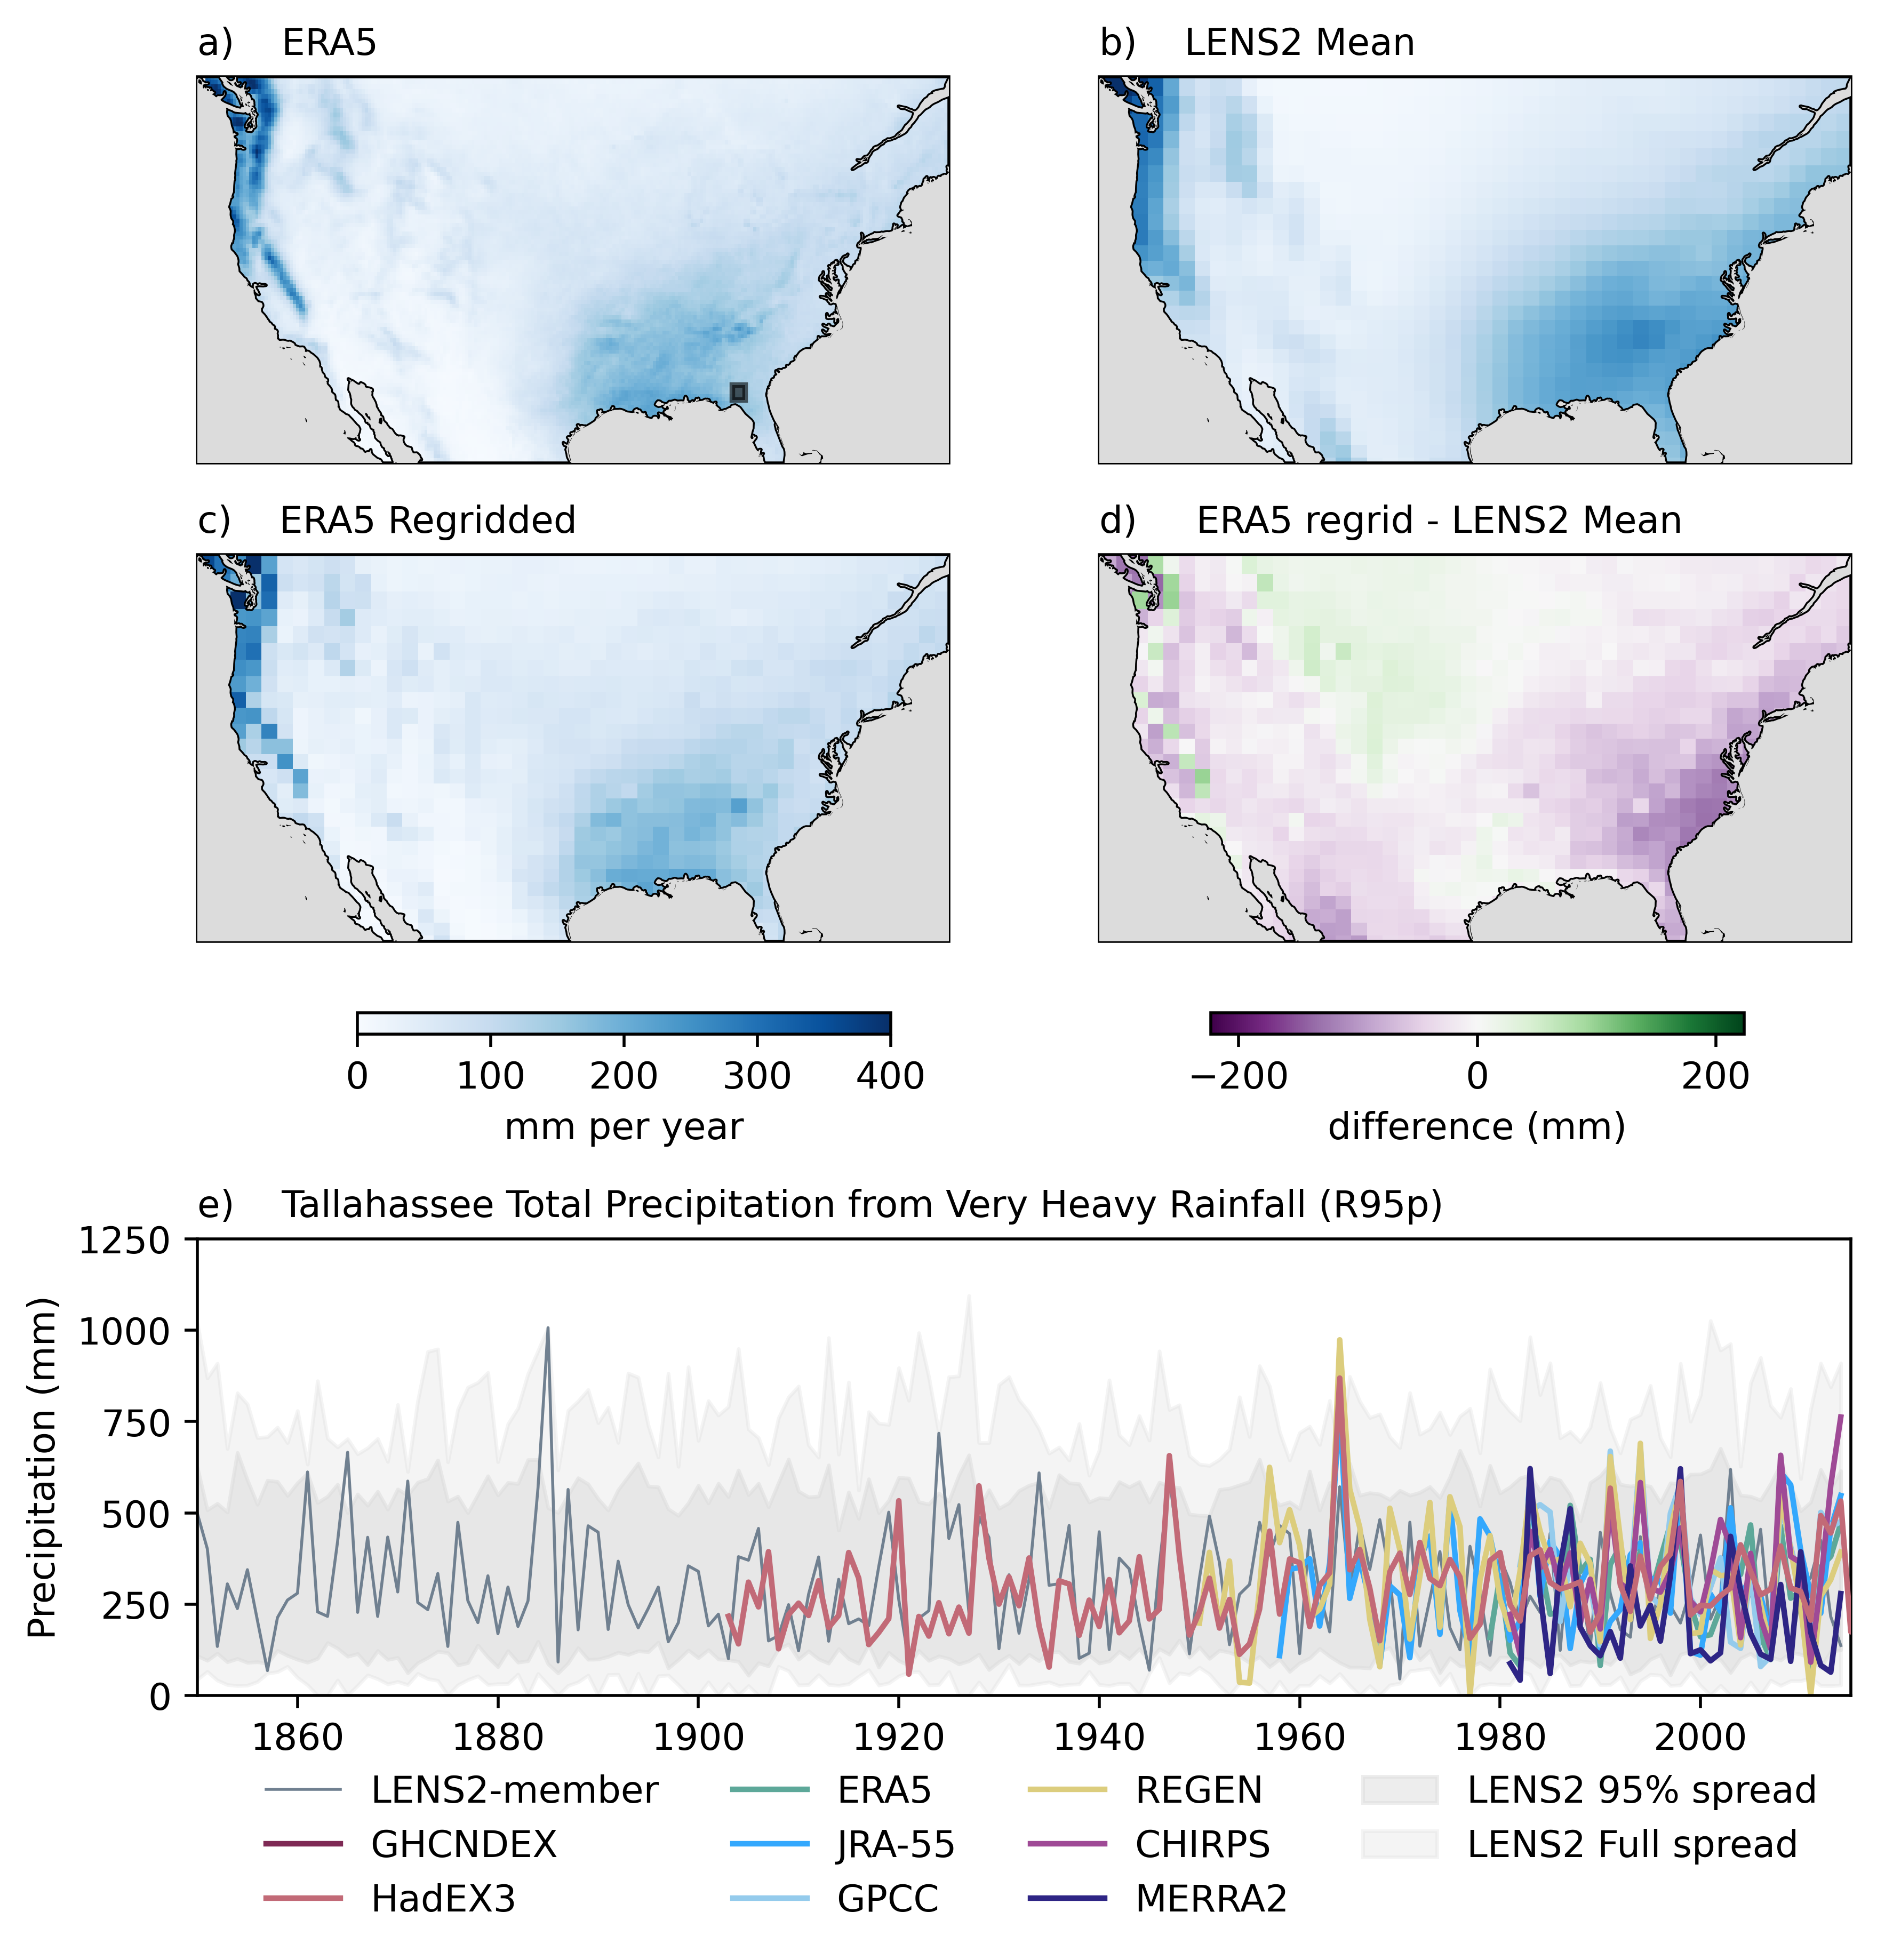

In [91]:
# Comparison of R95p to ERA5
fig = plt.figure(figsize=(8, 8), dpi=500)

# Set spacing between subplots, h/wsapce specified as a fraction of the size of the subplot group
#fig.set_constrained_layout_pads(hspace=0.07, wspace=0.03)

gs = fig.add_gridspec(2,1, hspace=0.4, height_ratios=[4,2])

gs0 = gs[0].subgridspec(2,2, hspace=0.1)
gs1 = gs[1].subgridspec(1,1)


vmin  = 0
vmax = 400


ax1 = fig.add_subplot(gs0[0, 0], projection=ccrs.Mercator())
pa = r95p_e5_4014.R95p.plot(
      cmap='Blues',
      vmin=vmin, vmax=vmax,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

ax1.set_title("a)    ERA5", loc='left', fontsize=10)
ax1.coastlines()
ax1.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax1.add_patch(rect)
ax1.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

ax2 = fig.add_subplot(gs0[0,1], projection=ccrs.Mercator())
pb = r95p_l2_m.R95p.plot(
      cmap='Blues',
      vmin=vmin, vmax=vmax,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

ax2.set_title("b)    LENS2 Mean", loc='left', fontsize=10)
ax2.coastlines()
ax2.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax2.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

ax3 = fig.add_subplot(gs0[1,0], projection=ccrs.Mercator())
pc = r95p_ellin_4014.R95p.plot(
      cmap='Blues',
      vmin=vmin, vmax=vmax,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)
ax3.set_title("c)    ERA5 Regridded", loc='left', fontsize=10)
ax3.coastlines()
ax3.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax3.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

ax4 = fig.add_subplot(gs0[1,1], projection=ccrs.Mercator())
pd = r95p_difflin.R95p.plot(
      cmap='PRGn',
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

ax4.set_title("d)     ERA5 regrid - LENS2 Mean", loc='left',fontsize=10)
ax4.coastlines()
ax4.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax4.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

cax = fig.add_axes([.2,0.42,0.25,0.01])
cbar_3 = plt.colorbar(pc, cax=cax, orientation='horizontal')
cbar_3.set_label(label = 'mm per year', size=10)
cbar_3.ax.tick_params(labelsize=10)

cbx = fig.add_axes([.6,0.42,0.25,0.01])
cbar_3 = plt.colorbar(pd, cax=cbx, orientation='horizontal')
cbar_3.set_label(label = 'difference (mm)', size=10)
cbar_3.ax.tick_params(labelsize=10)

ax5 = fig.add_subplot(gs1[0])

ax5.plot(dsr_tr95p.year, dsr_tr95p.R95p, label='LENS2-member', color='slategrey', linewidth=0.8)
ax5.plot(ghx_t.time.dt.year, ghx_t.R95p, label='GHCNDEX', color=(126/255, 41/255, 84/255), zorder=10)
ax5.plot(had_t.time.dt.year, had_t.R95p, label='HadEX3', color=(194/255,106/255,119/255), zorder=10)
ax5.plot(era_t.year, era_t.R95p, label='ERA5', color=(93/255,168/255,153/255))
ax5.plot(jra_t.year, jra_t.R95p, label='JRA-55', color=(51/255,168/255,253/255))
ax5.plot(gpc_t.year, gpc_t.R95p, label='GPCC', color=(148/255,203/255,236/255))
ax5.plot(reg_t.year, reg_t.R95p, label='REGEN', color=(220/255,205/255,125/255))
ax5.plot(chp_t.year, chp_t.R95p, label='CHIRPS', color= (159/255,74/255,150/255) )
ax5.plot((mer_t.year), mer_t.rain, label='MERRA2', color=(46/255,37/255,133/255))
ax5.fill_between(dsr_t5.year, dsr_t5.R95p, dsr_t95.R95p, alpha=0.5, color= 'gainsboro' , label='LENS2 95% spread')
ax5.fill_between(dsr_tmx.year, dsr_tmin.R95p, dsr_tmx.R95p, alpha=0.3, color='gainsboro', label='LENS2 Full spread')

ax5.set_xlim(1850,2015)
ax5.set_ylim(0,1250)
ax5.set_ylabel('Precipitation (mm)')
ax5.set_title('e)    Tallahassee Total Precipitation from Very Heavy Rainfall (R95p)', loc='left',fontsize=10)
ax5.legend(bbox_to_anchor=(1, -0.1), shadow=False, ncols = 4, frameon=False)

plt.savefig(join(plotpath,'Figure1_R95p_ONDJFM_ERA5_LENS2_FLts.pdf'),bbox_inches='tight', dpi=500)
plt.show()

### **Figure 2 Correlation IPV to R95p**


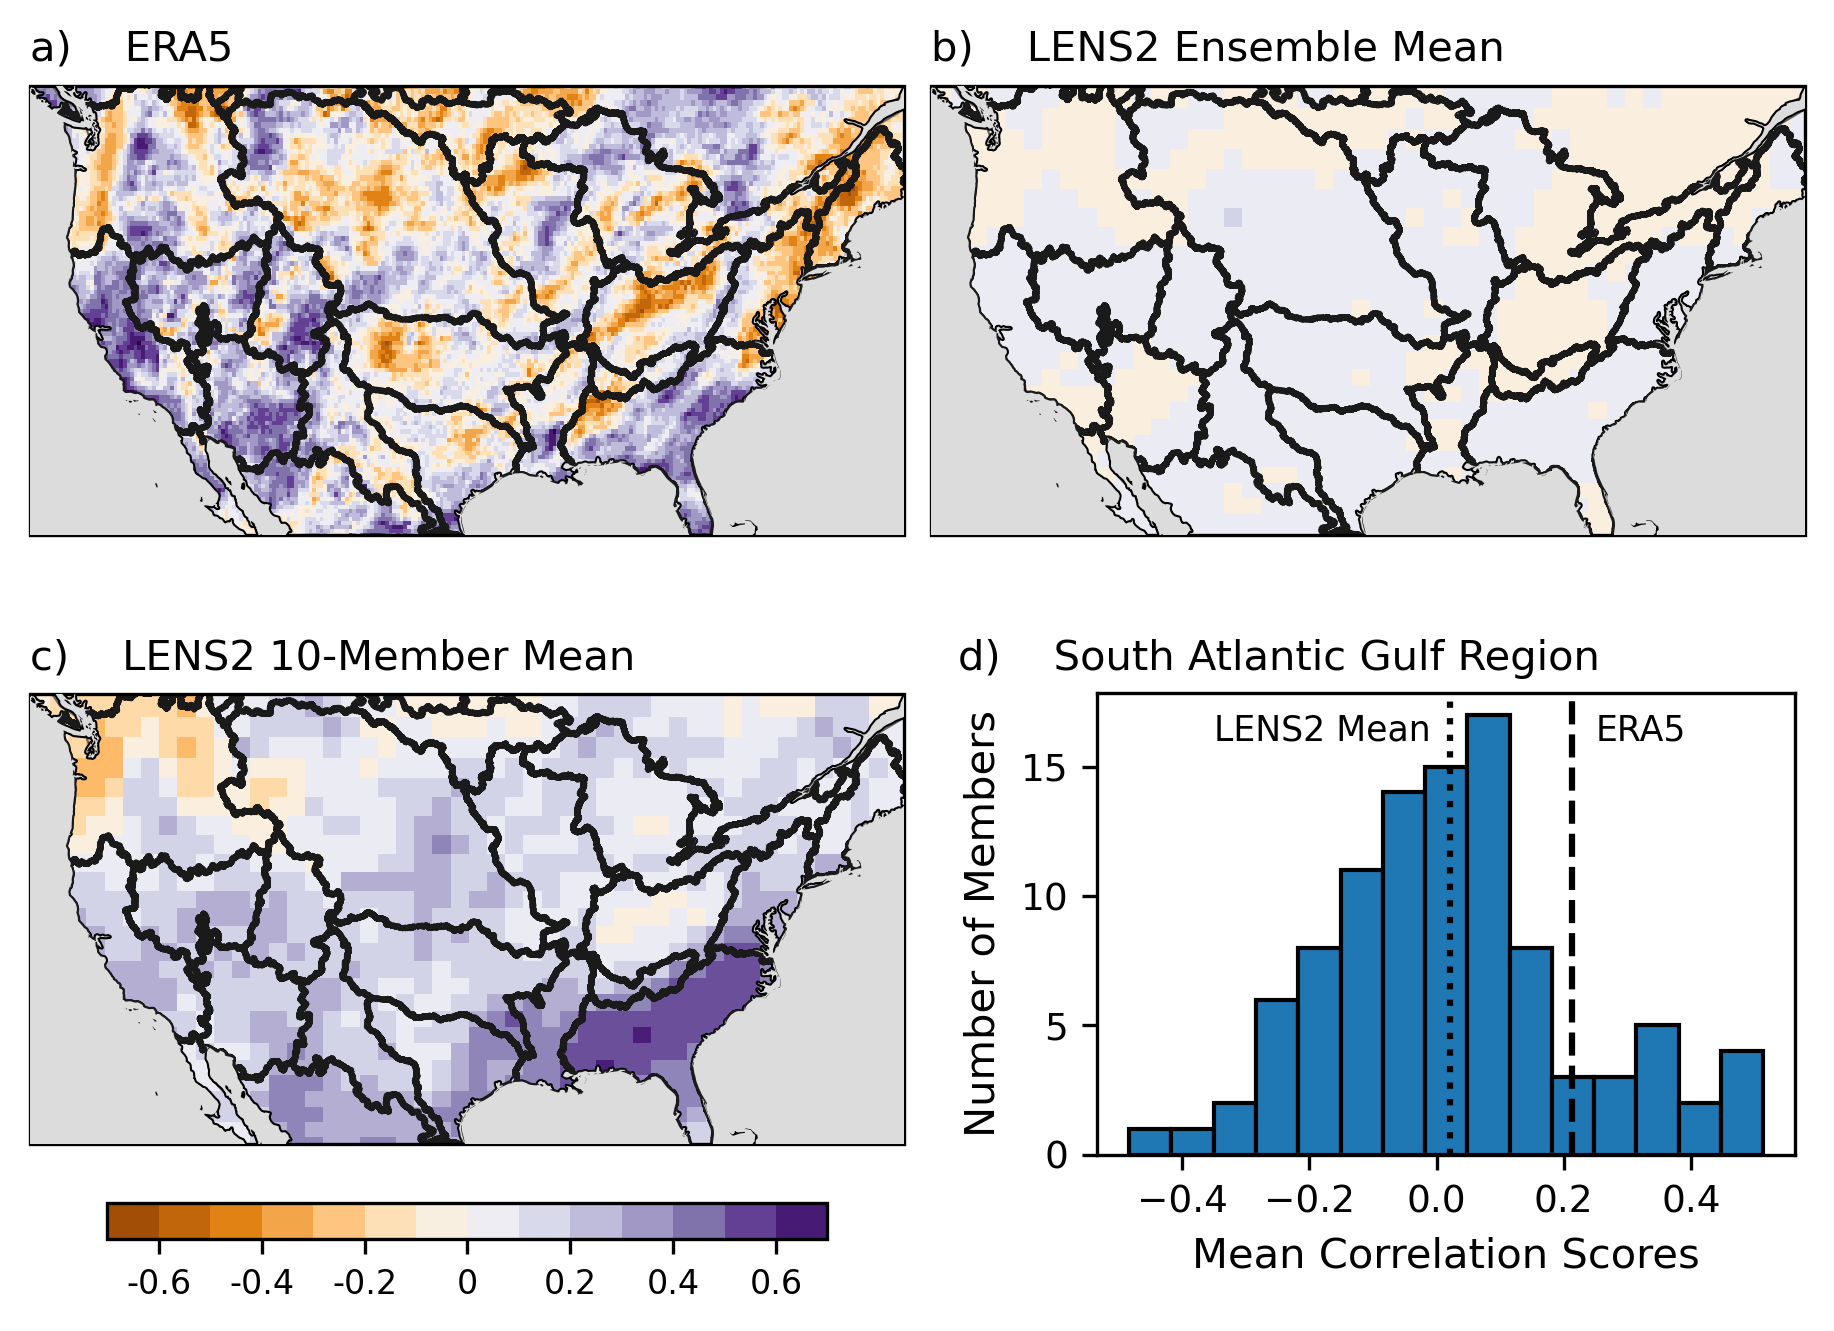

In [73]:
text_kws = dict(
    bbox = dict(color="none"),
    fontsize=8,
    color='none')

fig = plt.figure(figsize=(6, 4), constrained_layout=True, dpi=300)
#spec = gridspec.GridSpec(ncols=2, nrows=1, figure=fig)

# Set spacing between subplots, h/wspace specified as a fraction of the size of the subplot group
fig.set_constrained_layout_pads(hspace=0.07, wspace=0.03)
vmin  = -0.7
vmax = 0.7
cmap = plt.colormaps.get_cmap('PuOr')
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

ax1 = fig.add_subplot(2, 2, 1, projection=ccrs.Mercator())
pa = era_r95p_ipvh.corr.plot(
      vmin=vmin,vmax=vmax,levels=15,cmap=cmap, norm=norm,
      subplot_kws=dict(projection=ccrs.Robinson(), facecolor="gray"),
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

huc2_regions.plot(ax=ax1, text_kws = text_kws)

ax1.set_title("a)    ERA5", fontsize=10, loc='left')
ax1.coastlines()
ax1.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax1.set_extent([233,293,26,50], crs=ccrs.PlateCarree())


ax2 = fig.add_subplot(2, 2, 2, projection=ccrs.Mercator())
pc = r95p_lens_ipvh.cor.mean('member').plot(
      vmin=vmin,vmax=vmax,levels=15,cmap=cmap, norm=norm,
      subplot_kws=dict(projection=ccrs.Robinson(), facecolor="gray"),
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

huc2_regions.plot(ax=ax2, text_kws = text_kws)

ax2.set_title("b)    LENS2 Ensemble Mean", fontsize=10, loc='left')
ax2.coastlines()
ax2.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax2.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

ax3 = fig.add_subplot(2, 2, 3, projection=ccrs.Mercator())
pc = r95p_lens_ipvh_10.cor.plot(
      vmin=vmin,vmax=vmax,levels=15,cmap=cmap, norm=norm,
      subplot_kws=dict(projection=ccrs.Robinson(), facecolor="gray"),
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

huc2_regions.plot(ax=ax3, text_kws = text_kws)

ax3.set_title("c)    LENS2 10-Member Mean", fontsize=10, loc='left')
ax3.coastlines()
ax3.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax3.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

ax4 = fig.add_subplot(2,2,4)
# Get current position bounds: [left, bottom, width, height]
box = ax4.get_position()

# Adjust plotting box
ax4.set_position([0.6, 0.05, box.width*1.1, box.height *1.1])

# plot histogram chart for correlations
n_bins = 15
# get positions and heights of bars
heights, bins = np.histogram(weighted_cors.LENS2_cor, density=False, bins=n_bins) 
bin_width = np.diff(bins)[0]
bin_pos =( bins[:-1] + bin_width / 2) 

# plot histogram
plt.bar(bin_pos, heights, width=bin_width, edgecolor='black')
ax4.text(x=-0.2, y=1.05, s="d)    South Atlantic Gulf Region", 
        transform=ax4.transAxes, fontsize=10, ha='left')
ax4.set_xlabel('Mean Correlation Scores', fontsize=10)
ax4.set_ylabel('Number of Members')
ax4.axvline(weighted_cors.ERA5_cor, linestyle='dashed', color='black')
ax4.axvline(weighted_cors.LENS2_cor.mean('member'), linestyle='dotted', color='black')
ax4.text(-0.35, 16, 'LENS2 Mean', size='small')
ax4.text(0.25, 16, 'ERA5', size='small')
ax4.tick_params('both', labelsize=9)

cax = fig.add_axes([0.05,-0.02,0.4,0.03])
cbar_4 = plt.colorbar(pa, cax=cax, orientation='horizontal', extend='neither')
cbar_4.set_ticks(ticks=[-0.6,-0.4,-0.2, 0, 0.2,0.4,0.6], labels=['-0.6','-0.4','-0.2', '0', '0.2','0.4','0.6'])
cbar_4.ax.tick_params(labelsize=8)

plt.savefig(join(plotpath, 'Figure2_IPV_correlation_comparison.pdf'), dpi=500, bbox_inches='tight')
plt.show()

### Figure 3


Data for composite plots

In [16]:
era_comp_yr = era_ipvh['year'].where(era_ipvh.ipvh>=0.3, drop=True)

In [17]:
#original time dimension stored as datetime64 object. Rename the dimension
# then extract the year as an integer and replace the coordinate value
n95_era5_butter = n95_era5_butter.rename({'time':'year'})
n95_era5_butter['year'] = n95_era5_butter['year'].dt.year

In [18]:
r95p_era5_butter = r95p_era5_butter.rename({'time':'year'})
r95p_era5_butter['year'] = r95p_era5_butter['year'].dt.year

In [19]:
era_n95_comp = n95_era5_butter.sel(year=era_comp_yr).mean('year')
era_r95p_comp = r95p_era5_butter.sel(year=era_comp_yr).mean('year')

In [25]:
lens_ipvh_10 = lens_ipvh.sel(member=members_10)
lens_r95p_10 = r95p_lens_butter.sel(member=members_10)
lens_n95_10 = n95_lens_butter.sel(member=members_10)

In [26]:
# renumber members to match mask
lens_r95p_10['member'] = np.arange(0,10)
lens_n95_10['member'] = np.arange(0,10)

In [39]:
lens_mask10 = lens_ipvh_10 >=0.78

In [40]:
lens10_r95p_comp =  lens_r95p_10.where(lens_mask10.IPVH).mean(dim=['year', 'member'])
lens10_n95_comp = lens_n95_10.where(lens_mask10.IPVH).mean(dim=['year','member'])

In [159]:
lens_mask = lens_ipvh >=0.7
lens_r95p_comp = r95p_lens_butter.where(lens_mask.IPVH).mean(dim=['year','member'])
lens_n95_comp = n95_lens_butter.where(lens_mask.IPVH).mean(dim=['year','member'])

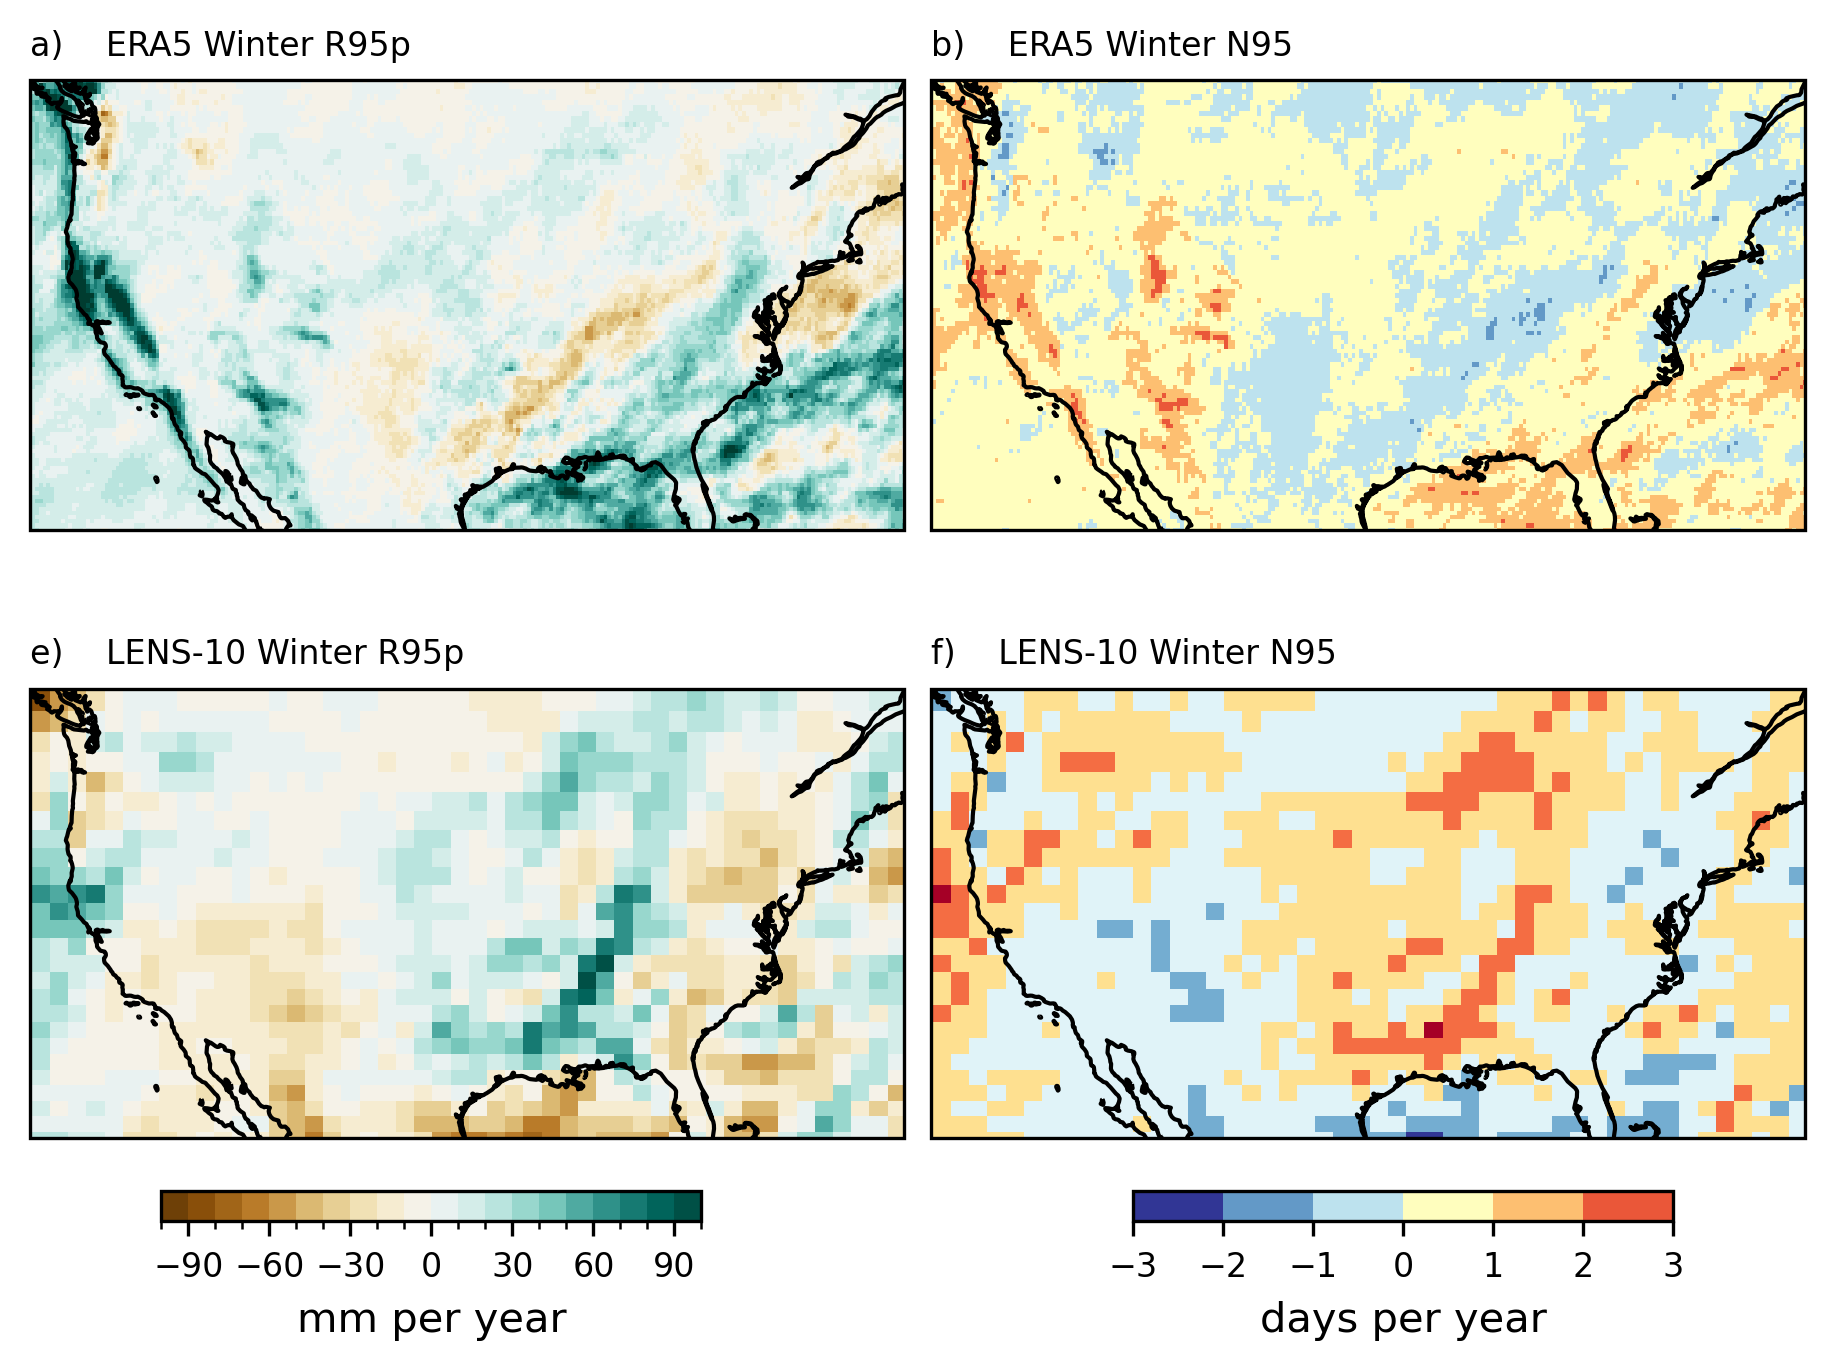

In [42]:
# Comparison of R95p to ERA5
fig = plt.figure(figsize=(6, 4), constrained_layout=True, dpi=300)

# Set spacing between subplots, h/wsapce specified as a fraction of the size of the subplot group
fig.set_constrained_layout_pads(hspace=0.07, wspace=0.03)
vmin  = -100
vmax = 100


ax1 = fig.add_subplot(2, 2, 1, projection=ccrs.Mercator())
pc = era_r95p_comp.R95p.plot(
      cmap='BrBG',
      vmin=vmin, vmax=vmax, levels=21,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

ax1.set_title("a)    ERA5 Winter R95p", loc='left', fontsize=8)
ax1.coastlines()
ax1.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

ax2 = fig.add_subplot(2, 2, 2, projection=ccrs.Mercator())
pd = era_n95_comp.N95.plot(
      cmap='RdYlBu_r',
      vmin=-3, vmax=3, levels=7,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

ax2.set_title("b)    ERA5 Winter N95", loc='left', fontsize=8)
ax2.coastlines()
ax2.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

ax3 = fig.add_subplot(2, 2, 3, projection=ccrs.Mercator())
pa = lens10_r95p_comp.R95p.plot(
      cmap='BrBG',
      vmin=vmin, vmax=vmax,levels=21,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

ax3.set_title("e)    LENS-10 Winter R95p", loc='left', fontsize=8)
ax3.coastlines()
ax3.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

ax4 = fig.add_subplot(2, 2, 4, projection=ccrs.Mercator())
pa = lens10_n95_comp.N95.plot(
      cmap='RdYlBu_r',
      vmin=-3, vmax=3, levels=7,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

ax4.set_title("f)    LENS-10 Winter N95", loc='left', fontsize=8)
ax4.coastlines()
ax4.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

cax = fig.add_axes([0.08,-0.01,0.3,0.025])
cbar_3 = plt.colorbar(pc, cax=cax, orientation='horizontal', extend='neither')
cbar_3.set_label(label = 'mm per year', size=10)
cbar_3.ax.tick_params(labelsize=8)

cbx = fig.add_axes([0.62,-0.01,0.3,0.025])
cbar_3 = plt.colorbar(pd, cax=cbx, orientation='horizontal', extend='neither')
cbar_3.set_label(label = 'days per year', size=10)
cbar_3.ax.tick_params(labelsize=8)

plt.savefig(join(plotpath,'Figure3_R95p_N95_IPVPos.pdf'),bbox_inches='tight')

plt.show()

## Supplemental Figures

Figure S2 : ERA5 seasonality

In [30]:
wy = [9,10,11,0,1,2,3,4,5,6,7,8] # order of months
wmons = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep']

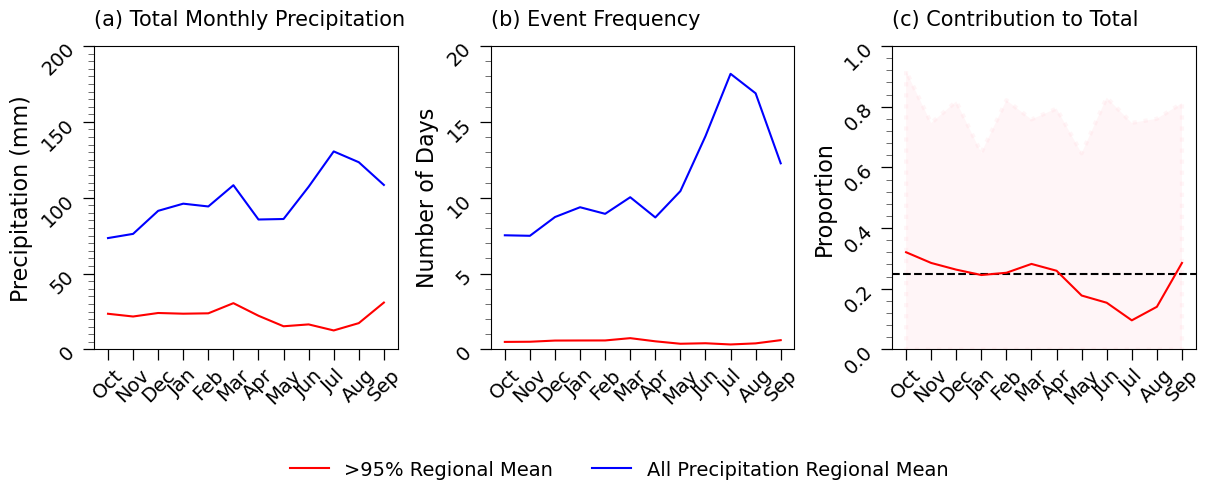

In [28]:
# version without full regional range
fig = plt.figure(figsize=(12, 5), constrained_layout=True)
spec = gridspec.GridSpec(ncols=3, nrows=1, figure=fig)

# Set spacing between subplots, h/wsapce specified as a fraction of the size of the subplot group
fig.set_constrained_layout_pads(hspace=0.07, wspace=0.03)

# Add the subplots
ax1 = fig.add_subplot(spec[0, 0])  # left cell of grid
ax2 = fig.add_subplot(spec[0, 1])  # middle
ax3 = fig.add_subplot(spec[0, 2])  # right

# Make sure subplots are square
for axes in [ax1, ax2, ax3]:
    axes.set_box_aspect(1)

t=range(12)

# plot a: Total Monthly Precipitations
ax1.plot(t,ptot_sag_mon_mean.MTPR[wy],color='blue')
ax1.plot(t,r95p_sag_mon_mean.P95[wy],color='red', zorder=10)
#ax1.fill_between(t,ptot_sag_mon_min.MTPR[wy], ptot_sag_mon_max.MTPR[wy], color='lightblue', alpha=0.15, linewidth=3, linestyle=':')
    # Use geocat.viz.util convenience function to set titles and labels
gvutil.set_titles_and_labels(ax1, ylabel='Precipitation (mm)', xlabel='',
                                lefttitle="(a) Total Monthly Precipitation", lefttitlefontsize=15)
gvutil.set_axes_limits_and_ticks(ax1,
                             ylim=(0, 200),
                             xticks=t,
                             xticklabels=wmons,)
# Use geocat.viz.util convenience function to add minor and major tick lines
gvutil.add_major_minor_ticks(ax1,
                         x_minor_per_major=1,
                         y_minor_per_major=10,
                         labelsize=14)
ax1.tick_params(direction='out', which='both', right=False, top=False, labelbottom=True, labelrotation=45)


# plot c: Number of days
# Plot data
ax2.plot(t,wday_sag_mon_mean.MTPR[wy],color='blue')
        # Use geocat.viz.util convenience function to add minor and major tick lines
ax2.plot(t,n95_sag_mon_mean.P95[wy],color='red', zorder=10)
gvutil.add_major_minor_ticks(ax2,
                                 x_minor_per_major=1,
                                 y_minor_per_major=5,
                                 labelsize=14)
ax2.tick_params(direction='out', which='both', right=False, top=False, labelbottom=True, labelrotation=45)
    # Use geocat.viz.util convenience function to set titles and labels
gvutil.set_titles_and_labels(ax2, ylabel='Number of Days', xlabel='',
                                lefttitle="(b) Event Frequency", lefttitlefontsize=15)
gvutil.set_axes_limits_and_ticks(ax2,
                             ylim=(0, 20),
                             xticks=t,
                             xticklabels=wmons,)
 
#n95
ax3.plot(t,prop_sag_mon_mean['__xarray_dataarray_variable__'][wy],color='red', zorder=10)
plt.axhline(y=0.25, color='black', linestyle='--')
ax3.fill_between(t,prop_sag_mon_min['__xarray_dataarray_variable__'][wy], prop_sag_mon_max['__xarray_dataarray_variable__'][wy], color='pink', alpha=0.15, linewidth=3, linestyle=':')

gvutil.add_major_minor_ticks(ax3,
                                 x_minor_per_major=1,
                                 y_minor_per_major=5,
                                 labelsize=14)
ax3.tick_params(direction='out', which='both', right=False, top=False, labelbottom=True, labelrotation=45)
    # Use geocat.viz.util convenience function to set titles and labels
gvutil.set_titles_and_labels(ax3, ylabel='Proportion', xlabel='',
                                lefttitle="(c) Contribution to Total", lefttitlefontsize=15)
gvutil.set_axes_limits_and_ticks(ax3,
                             ylim=(0, 1),
                             xticks=t,
                             xticklabels=wmons,)



# add a legend
cyan_line = Line2D([0], [0], color='blue', label = 'All Precipitation Regional Mean')
red_line = Line2D([0], [0], color='red', label='>95% Regional Mean')
fig.legend(handles=[red_line, cyan_line],frameon=False, fontsize=14, bbox_to_anchor=(0.8,.01), ncols=2)

plt.savefig(join(plotpath, 'Supp2_ERA5_seasonality.png', dpi=600))
plt.show()

### Supplemental 3: comparison between observational products

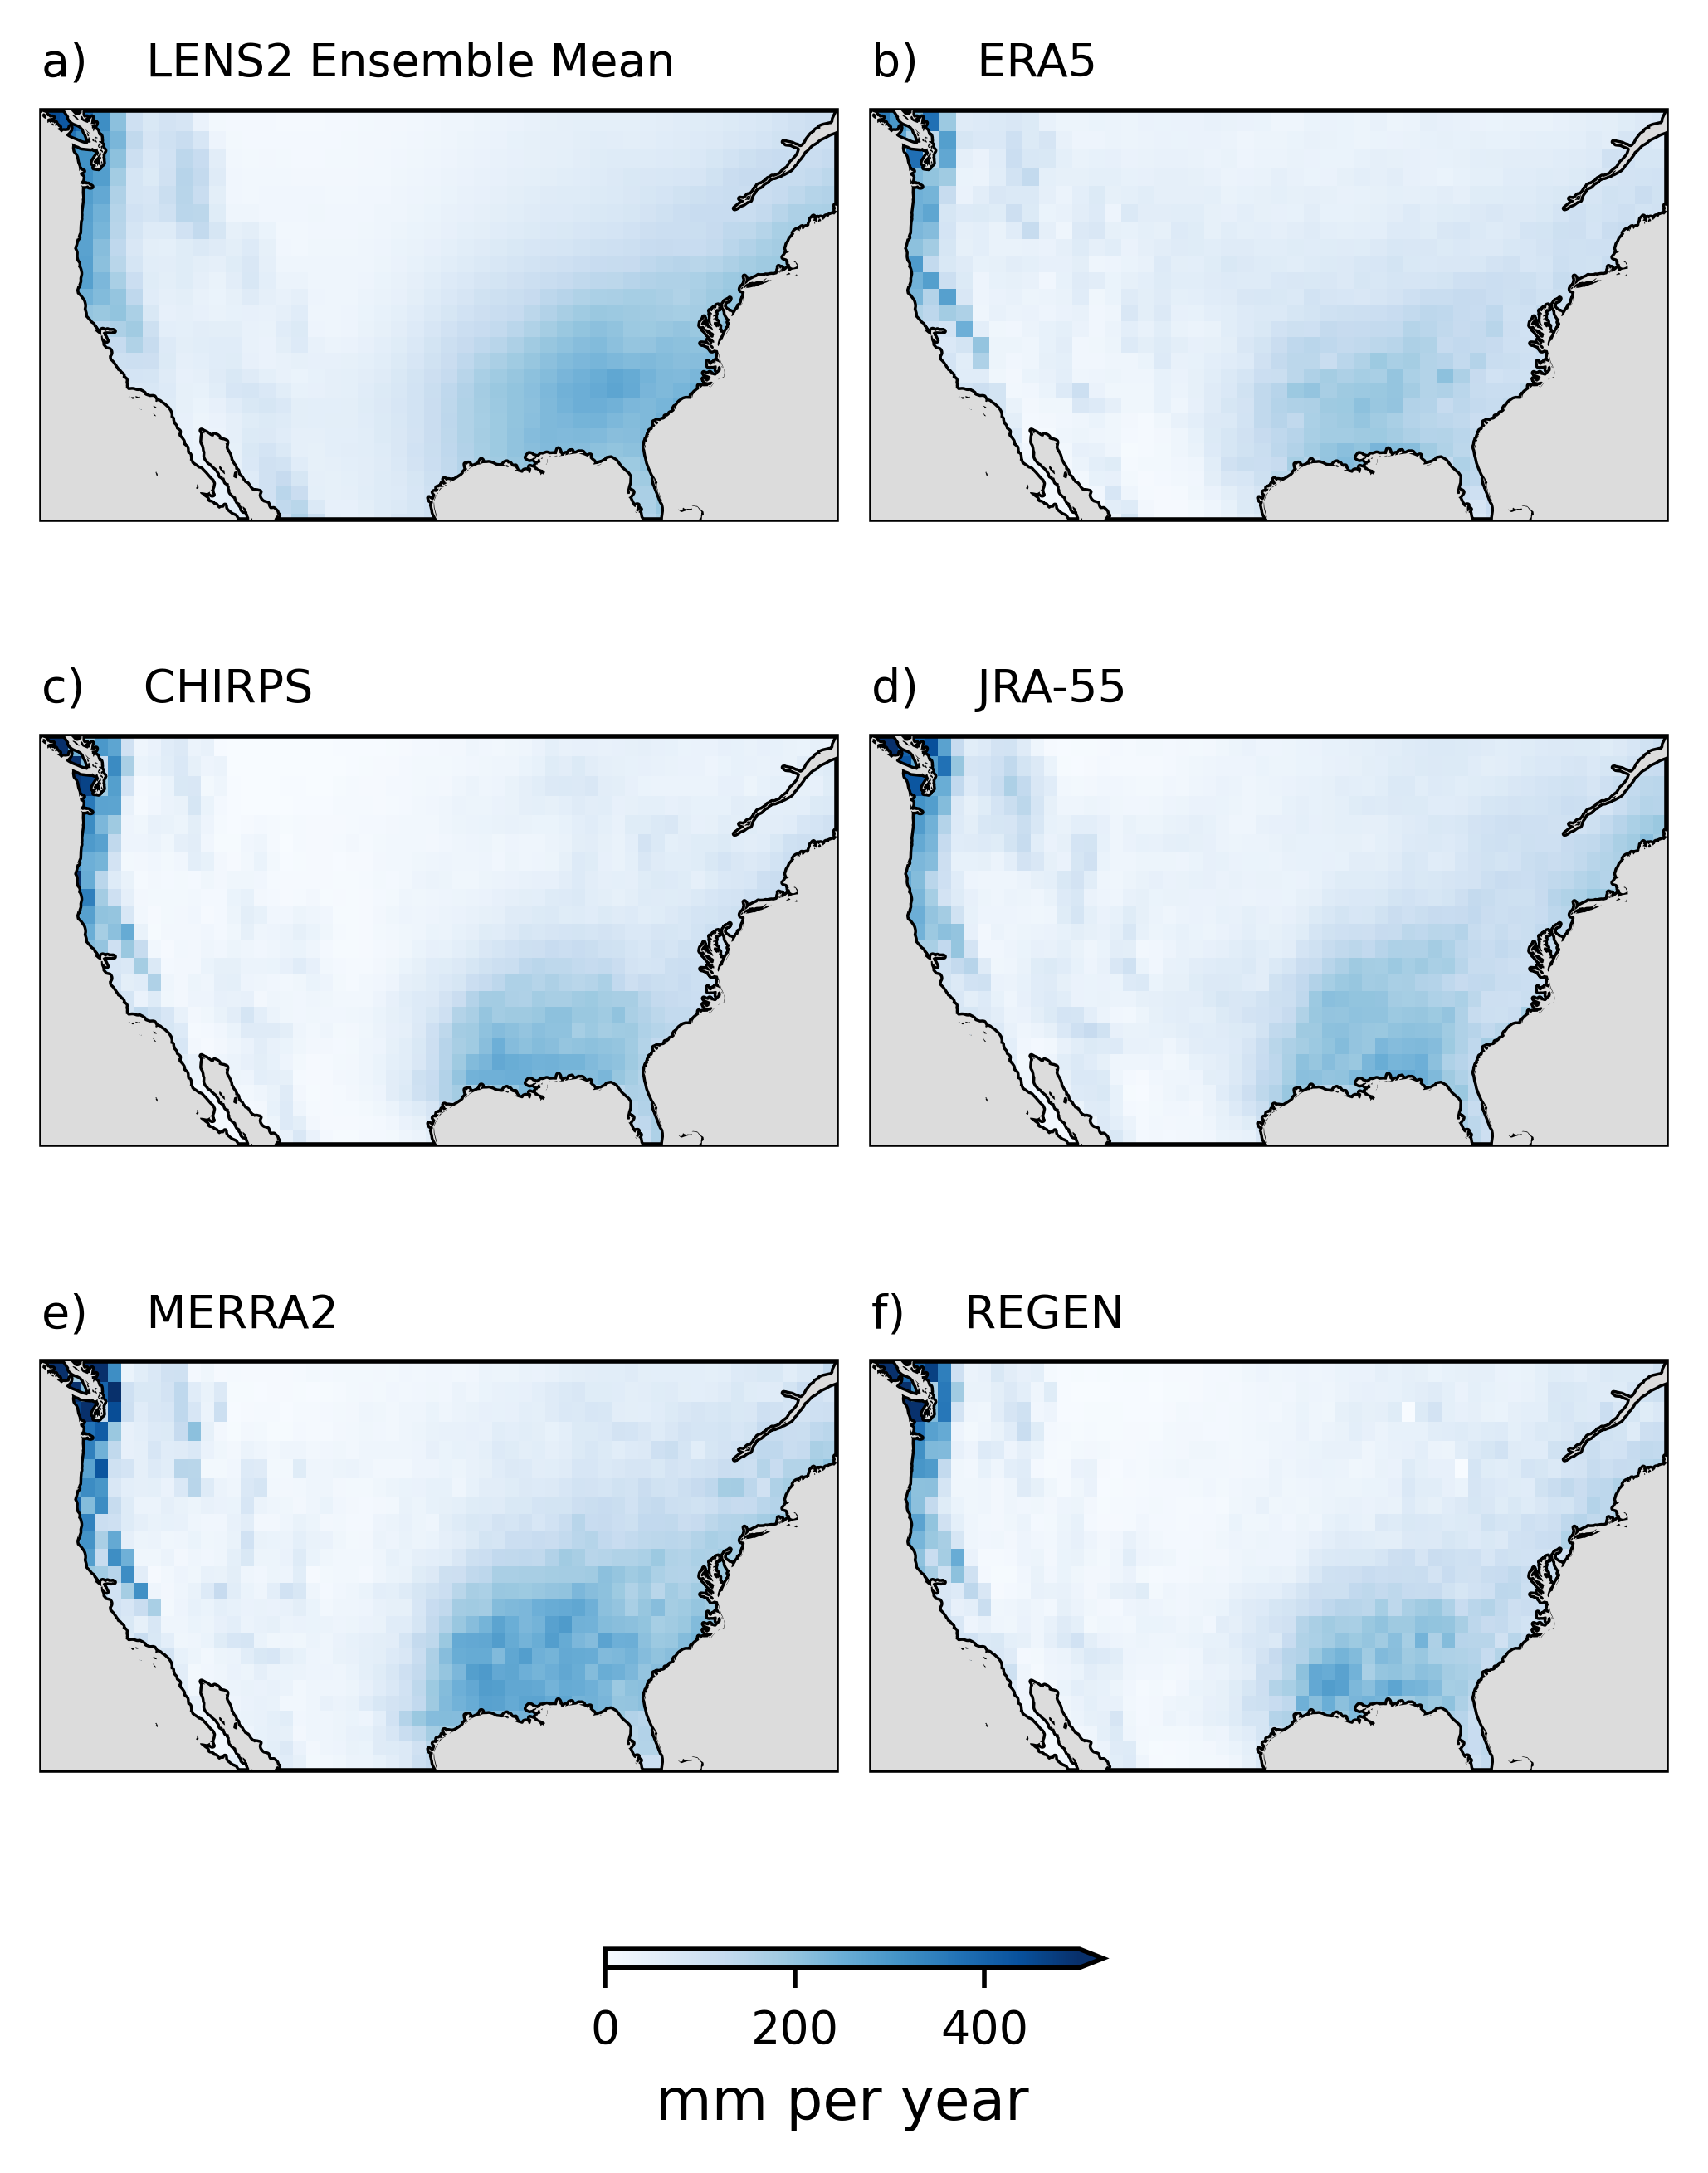

In [106]:
# R95p comparison of LENS and observations
fig = plt.figure(figsize=(4, 4.5), constrained_layout=True, dpi=500)

# Set spacing between subplots, h/wsapce specified as a fraction of the size of the subplot group
fig.set_constrained_layout_pads(hspace=0.07, wspace=0.03)
vmin  = 0
vmax = 500

ax1 = fig.add_subplot(3, 2, 1, projection=ccrs.Mercator())
pa = r95p_l2_8110.R95p.plot(
      cmap='Blues',
      vmax = vmax, vmin=vmin,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)
ax1.set_title("a)    LENS2 Ensemble Mean", fontsize=8, loc='left')
ax1.coastlines()
ax1.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax1.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

ax2 = fig.add_subplot(3, 2, 2, projection=ccrs.Mercator())
pb = r95p_ellin_8110.R95p.plot(
      cmap='Blues',
      vmax = vmax, vmin=vmin,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

ax2.set_title("b)    ERA5", fontsize=8, loc='left')
ax2.coastlines()
ax2.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax2.set_extent([233,293,26,50], crs=ccrs.PlateCarree())


ax3 = fig.add_subplot(3, 2, 3, projection=ccrs.Mercator())
pc = r95p_c_8110.rain.plot(
      cmap='Blues',
      vmax = vmax, vmin=vmin,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)
ax3.set_title("c)    CHIRPS", fontsize=8, loc='left')
ax3.coastlines()
ax3.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax3.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

ax4 = fig.add_subplot(3, 2, 4, projection=ccrs.Mercator())
pd = r95p_j_8110.rain.plot(
      cmap='Blues',
      vmax = vmax, vmin=vmin,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

ax4.set_title("d)    JRA-55", fontsize=8, loc='left')
ax4.coastlines()
ax4.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax4.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

ax5 = fig.add_subplot(3, 2, 5, projection=ccrs.Mercator())
pd = r95p_m_8110.rain.plot(
      cmap='Blues',
      vmax = vmax, vmin=vmin,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

ax5.set_title("e)    MERRA2", fontsize=8, loc='left')
ax5.coastlines()
ax5.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax5.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

ax6 = fig.add_subplot(3, 2, 6, projection=ccrs.Mercator())
pd = r95p_r_8110.rain.plot(
      cmap='Blues',
      vmax = vmax, vmin=vmin,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

ax6.set_title("f)    REGEN", fontsize=8, loc='left')
ax6.coastlines()
ax6.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax6.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

cax = fig.add_axes([0.35,-0.05,0.3,0.01])
cbar_3 = plt.colorbar(pc, cax=cax, orientation='horizontal', extend='max')
cbar_3.set_label(label = 'mm per year', size=10)
cbar_3.ax.tick_params(labelsize=8)


#plt.suptitle('ONDJFM Total Precipitation >95% 1981-2010')
plt.savefig(join(plotpath,'Supp3_R95p_ONDJFM_OBS_LENS2_1981-2010.pdf'),bbox_inches='tight')
plt.show()

### Supplemental 4

In [44]:
lens_ipvh_rank = lens_ipvh.sortby(weighted_cors.LENS2_cor,ascending=False)

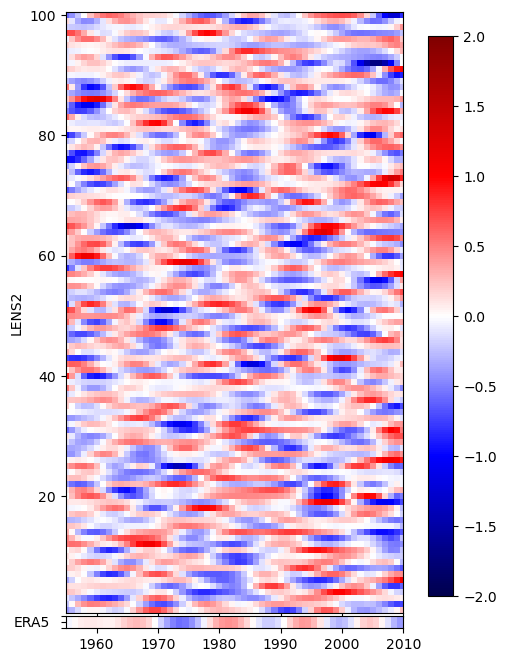

In [141]:
fig = plt.figure(figsize=(5,8))
cmap = plt.colormaps.get_cmap('seismic')

gs = gridspec.GridSpec(2, 1, height_ratios=[50, 1], hspace=0.01)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

#fig.suptitle('IPV')
# all LENS2 IPV ranked with best correlations at top
pc = ax1.pcolormesh(lens_ipvh_rank.year, lens_ipvh_rank.member, lens_ipvh_rank.IPVH,cmap=cmap, vmin=-2, vmax=2)
plt.xlim(1955,2010)
#ax1.yaxis.set_inverted(True) # which row is the best correlated member?!
ax1.set_ylabel('LENS2')
ax1.label_outer()

# add ERA5 as flattened 2-D array
z_data = np.array([era_ipvh.ipvh.values[:63]])
x_data = np.array([era_ipvh.year.values])
Y = np.array([0.5,1.5])
ax2.pcolormesh(x_data, Y, z_data, cmap=cmap, vmin=-2, vmax=2)
plt.xlim(1955,2010)
# Hide x labels and tick labels for all but bottom plot.
#for ax in axs:
#    ax.label_outer()

plt.setp(ax2.get_yticklabels(), visible=False)
ax2.set_ylabel('ERA5', rotation='horizontal')
ax2.yaxis.set_label_coords(-0.1,-0.1)


fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(pc, cax=cbar_ax)

plt.savefig(join(plotpath, 'Supplemental4_IPV_LENS2_ERA5.pdf'), dpi=300, bbox_inches="tight")
plt.show()

##### Supplemental Figure 5
Transitional correlations relating from yearly to 11 year data smooths

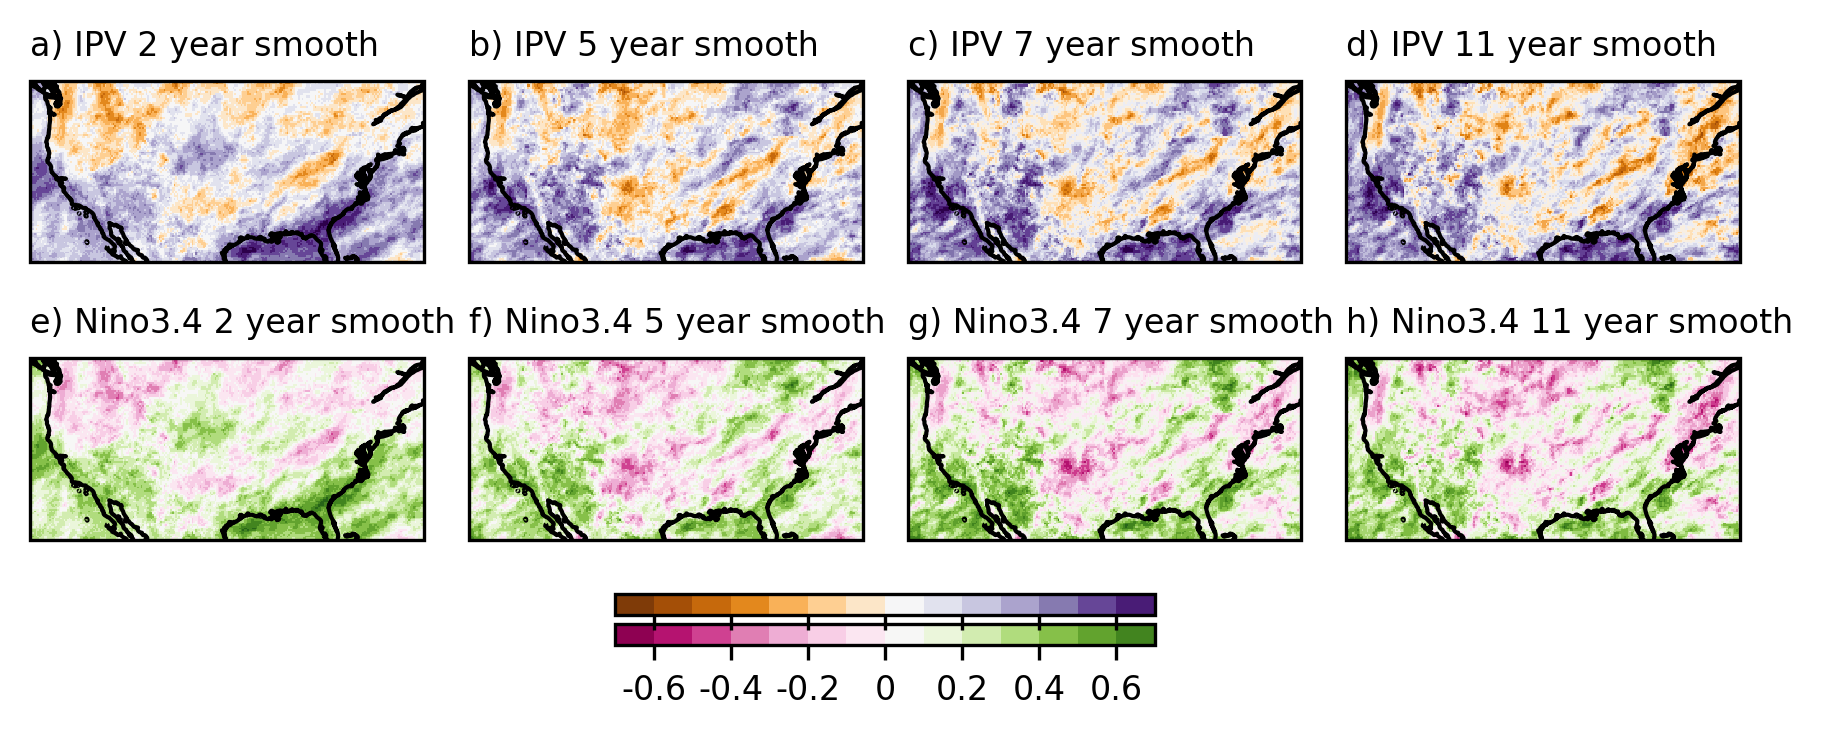

In [37]:
# Comparison of correlations with smoothing in ERA5

fig = plt.figure(figsize=(6, 2), dpi=300)

# Set spacing between subplots, h/wspace specified as a fraction of the size of the subplot group
#fig.set_constrained_layout_pads(hspace=0.05, wspace=0.03)
vmin  = -.7
vmax = .7
cmapi = 'PuOr'
cmapn = 'PiYG'
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

ax1 = fig.add_subplot(2, 4, 1, projection=ccrs.Mercator())
pc = r95p_era_multiyr.IPVH_2y.plot(
      cmap=cmapi,
      vmin=vmin, vmax=vmax, levels=15, norm=norm,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

ax1.set_title("a) IPV 2 year smooth", loc='left', fontsize=8)
ax1.coastlines()
ax1.set_extent([233,293,26,50], crs=ccrs.PlateCarree())
ax1.set_aspect('auto')

ax2 = fig.add_subplot(2, 4, 2, projection=ccrs.Mercator())
r95p_era_multiyr.IPVH_5y.plot(
      cmap=cmapi,
      vmin=vmin, vmax=vmax, levels=15, norm=norm,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

ax2.set_title("b) IPV 5 year smooth", loc='left', fontsize=8)
ax2.coastlines()
ax2.set_extent([233,293,26,50], crs=ccrs.PlateCarree())
ax2.set_aspect('auto')

ax3 = fig.add_subplot(2, 4, 3, projection=ccrs.Mercator())
r95p_era_multiyr.IPVH_7y.plot(
      cmap=cmapi,
      vmin=vmin, vmax=vmax, levels=15, norm=norm,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)
ax3.set_aspect('auto')
ax3.set_title("c) IPV 7 year smooth", loc='left', fontsize=8)
ax3.coastlines()
ax3.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

ax4 = fig.add_subplot(2, 4, 4, projection=ccrs.Mercator())
r95p_era_multiyr.IPVH_11y.plot(
      cmap=cmapi,
      vmin=vmin, vmax=vmax, levels=15, norm=norm,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)
ax4.set_aspect('auto')
ax4.set_title("d) IPV 11 year smooth", loc='left', fontsize=8)
ax4.coastlines()
ax4.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

ax5 = fig.add_subplot(2, 4, 5, projection=ccrs.Mercator())
pa = r95p_era_multiyr.NINO34_2y.plot(
      cmap=cmapn,
      vmin=vmin, vmax=vmax, levels=15, norm=norm,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)
ax5.set_aspect('auto')
ax5.set_title("e) Nino3.4 2 year smooth", loc='left', fontsize=8)
ax5.coastlines()
ax5.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

ax6 = fig.add_subplot(2, 4, 6, projection=ccrs.Mercator())
r95p_era_multiyr.NINO34_5y.plot(
      cmap=cmapn,
      vmin=vmin, vmax=vmax, levels=15, norm=norm,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)
ax6.set_aspect('auto')
ax6.set_title("f) Nino3.4 5 year smooth", loc='left', fontsize=8)
ax6.coastlines()
ax6.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

ax7 = fig.add_subplot(2, 4, 7, projection=ccrs.Mercator())
r95p_era_multiyr.NINO34_7y.plot(
      cmap=cmapn,
      vmin=vmin, vmax=vmax, levels=15, norm=norm,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)
ax7.set_aspect('auto')
ax7.set_title("g) Nino3.4 7 year smooth", loc='left', fontsize=8)
ax7.coastlines()
ax7.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

ax8 = fig.add_subplot(2, 4, 8, projection=ccrs.Mercator())
r95p_era_multiyr.NINO34_11y.plot(
      cmap=cmapn,
      vmin=vmin, vmax=vmax, levels=15, norm=norm,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)
ax8.set_aspect('auto')
ax8.set_title("h) Nino3.4 11 year smooth", loc='left', fontsize=8)
ax8.coastlines()
ax8.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

cax = fig.add_axes([0.35,-0.1,0.3,0.035])
cbar_3 = plt.colorbar(pa, cax=cax, orientation='horizontal', extend='neither')
cbar_3.set_label(label = '', size=10)
cbar_3.set_ticks(ticks=[-0.6,-0.4,-0.2, 0, 0.2,0.4,0.6], labels=['-0.6','-0.4','-0.2', '0', '0.2','0.4','0.6'])
cbar_3.ax.tick_params(labelsize=8)

caxt = fig.add_axes([0.35,-0.05,0.3,0.035])
cbar_4 = plt.colorbar(pc, cax=caxt, orientation='horizontal', extend='neither')
cbar_4.set_label(label = '', size=10)
cbar_4.set_ticks(ticks=[-0.6,-0.4,-0.2, 0, 0.2,0.4,0.6], labels=['','','', '', '','',''])
cbar_4.ax.tick_params(labelsize=8)

plt.subplots_adjust(hspace=0.25)
plt.tight_layout()
plt.savefig(join(plotpath,'Supp5_smoothing_corrs_IPVH_NINO34.pdf'),bbox_inches='tight')

plt.show()

###### Supplemental Figs 6 and 7 comparing correlations with PDV and Nino34

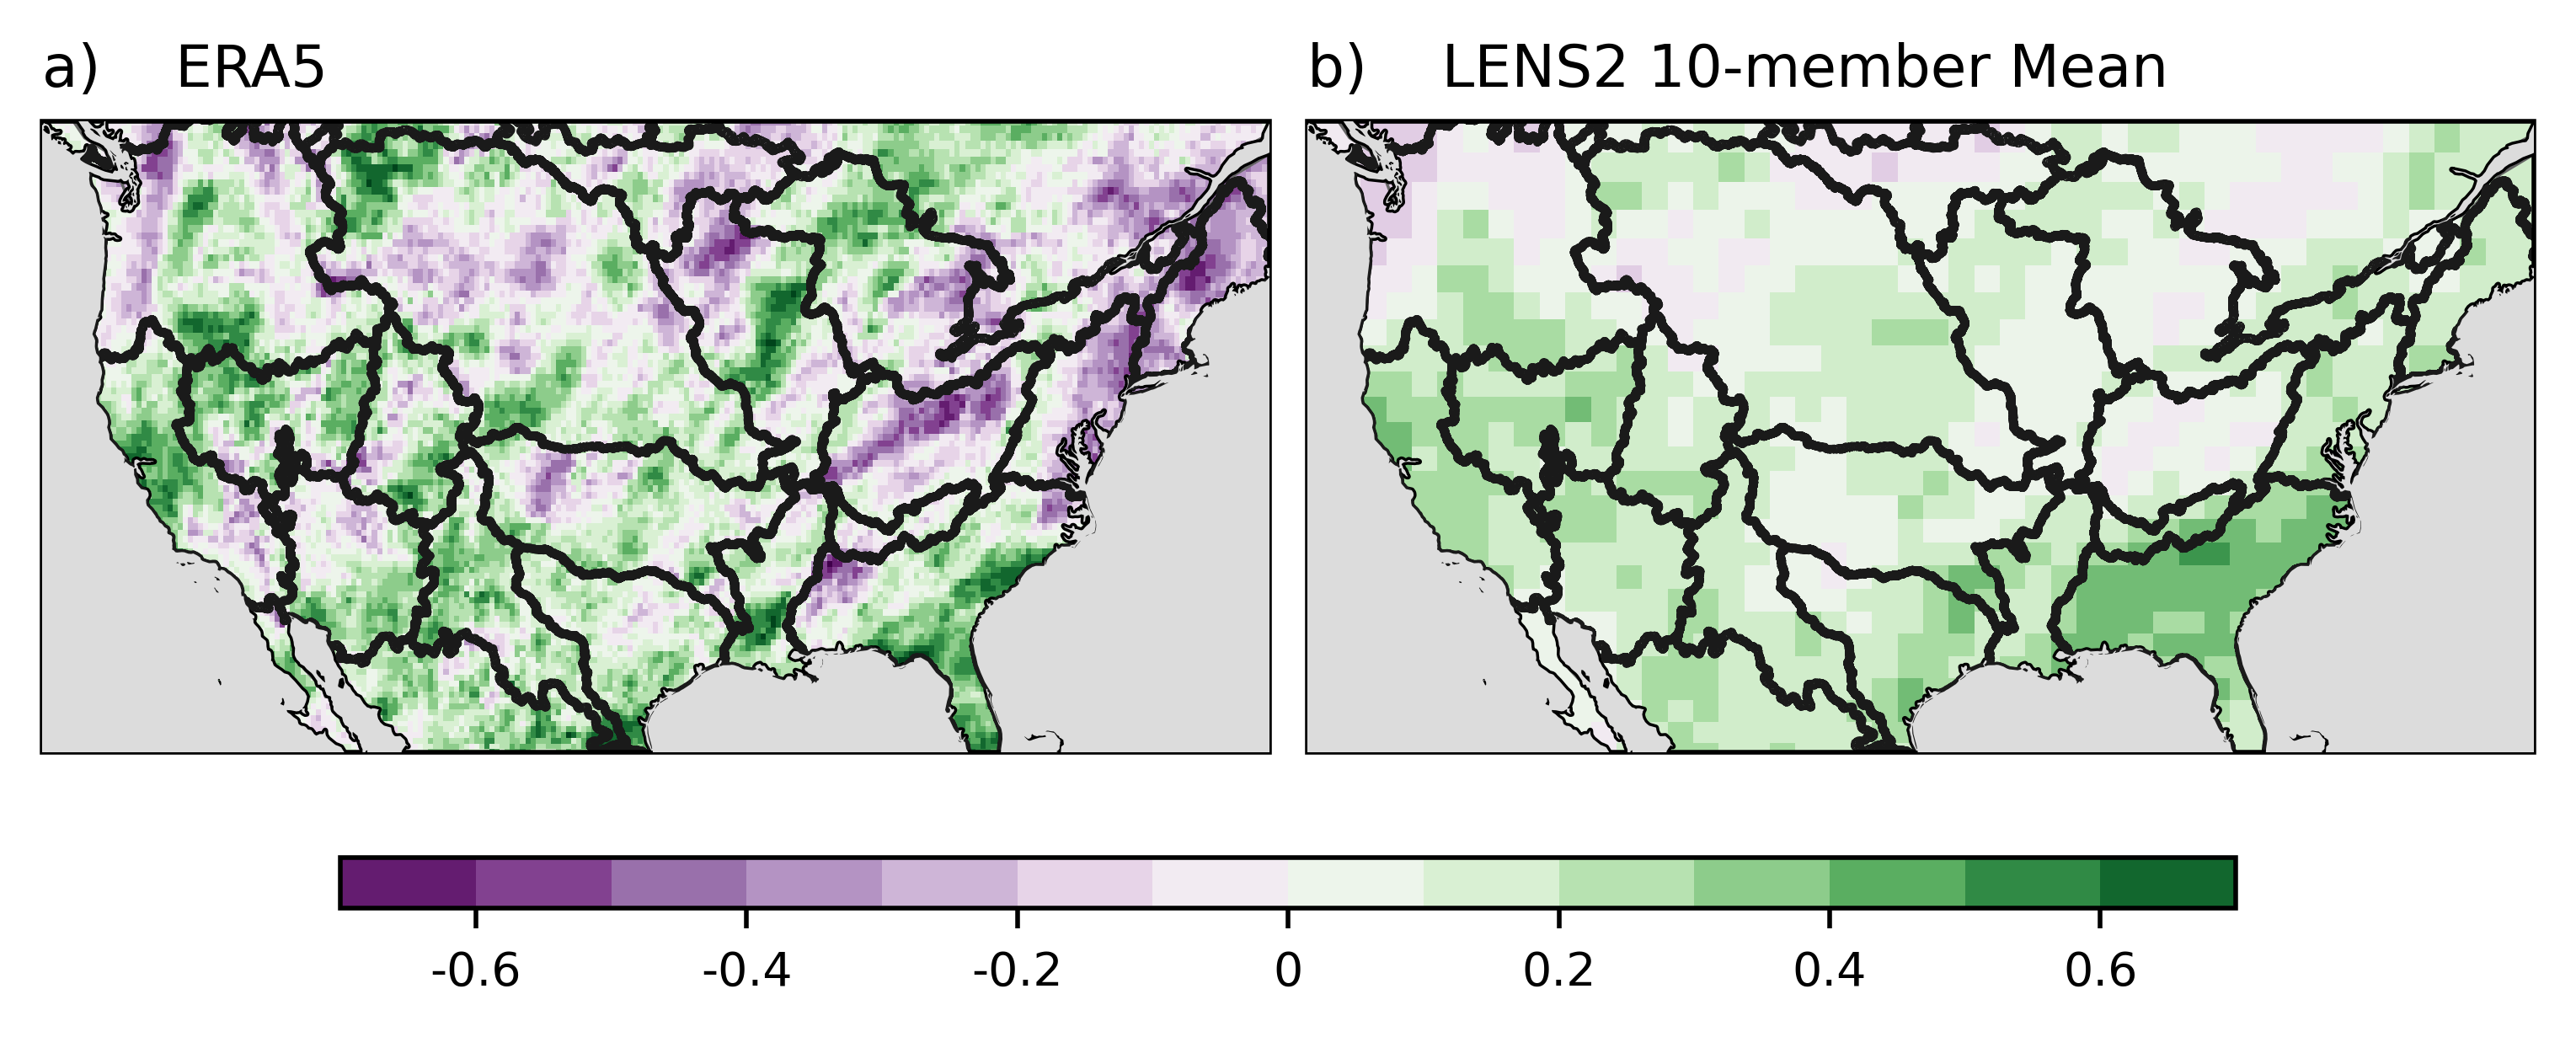

In [74]:
text_kws = dict(
    bbox = dict(color="none"),
    fontsize=8,
    color='none')

fig = plt.figure(figsize=(6, 4), constrained_layout=True, dpi=500)
#spec = gridspec.GridSpec(ncols=2, nrows=1, figure=fig)
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# Set spacing between subplots, h/wsapce specified as a fraction of the size of the subplot group
fig.set_constrained_layout_pads(hspace=0.07, wspace=0.03)
vmin  = -0.7
vmax = 0.7
cmap = plt.colormaps.get_cmap('PRGn')
##### panel non etc
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.Mercator())
pa = era_r95p_pdv.corr.plot(
      vmin=vmin,vmax=vmax,levels=15,cmap=cmap, norm=norm,
      subplot_kws=dict(projection=ccrs.Robinson(), facecolor="gray"),
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

huc2_regions.plot(ax=ax1, text_kws = text_kws)

ax1.set_title("a)    ERA5", fontsize=10, loc='left')
ax1.coastlines()
ax1.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax1.set_extent([233,293,26,50], crs=ccrs.PlateCarree())


ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.Mercator())
pc = r95p_lens_pdv_10.cor.plot(
      vmin=vmin,vmax=vmax,levels=15,cmap=cmap, norm=norm,
      subplot_kws=dict(projection=ccrs.Robinson(), facecolor="gray"),
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

huc2_regions.plot(ax=ax2, text_kws = text_kws)

ax2.set_title("b)    LENS2 10-member Mean", fontsize=10, loc='left')
ax2.coastlines()
ax2.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax2.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

cax = fig.add_axes([0.125,0.22,0.75,0.03])
cbar_4 = plt.colorbar(pa, cax=cax, orientation='horizontal', extend='neither')
cbar_4.set_ticks(ticks=[-0.6,-0.4,-0.2, 0, 0.2,0.4,0.6], labels=['-0.6','-0.4','-0.2', '0', '0.2','0.4','0.6'])
cbar_4.ax.tick_params(labelsize=8)

plt.savefig(join(plotpath, 'Supp6_PDV_correlation_comparison.pdf'), dpi=500, bbox_inches='tight')
plt.show()

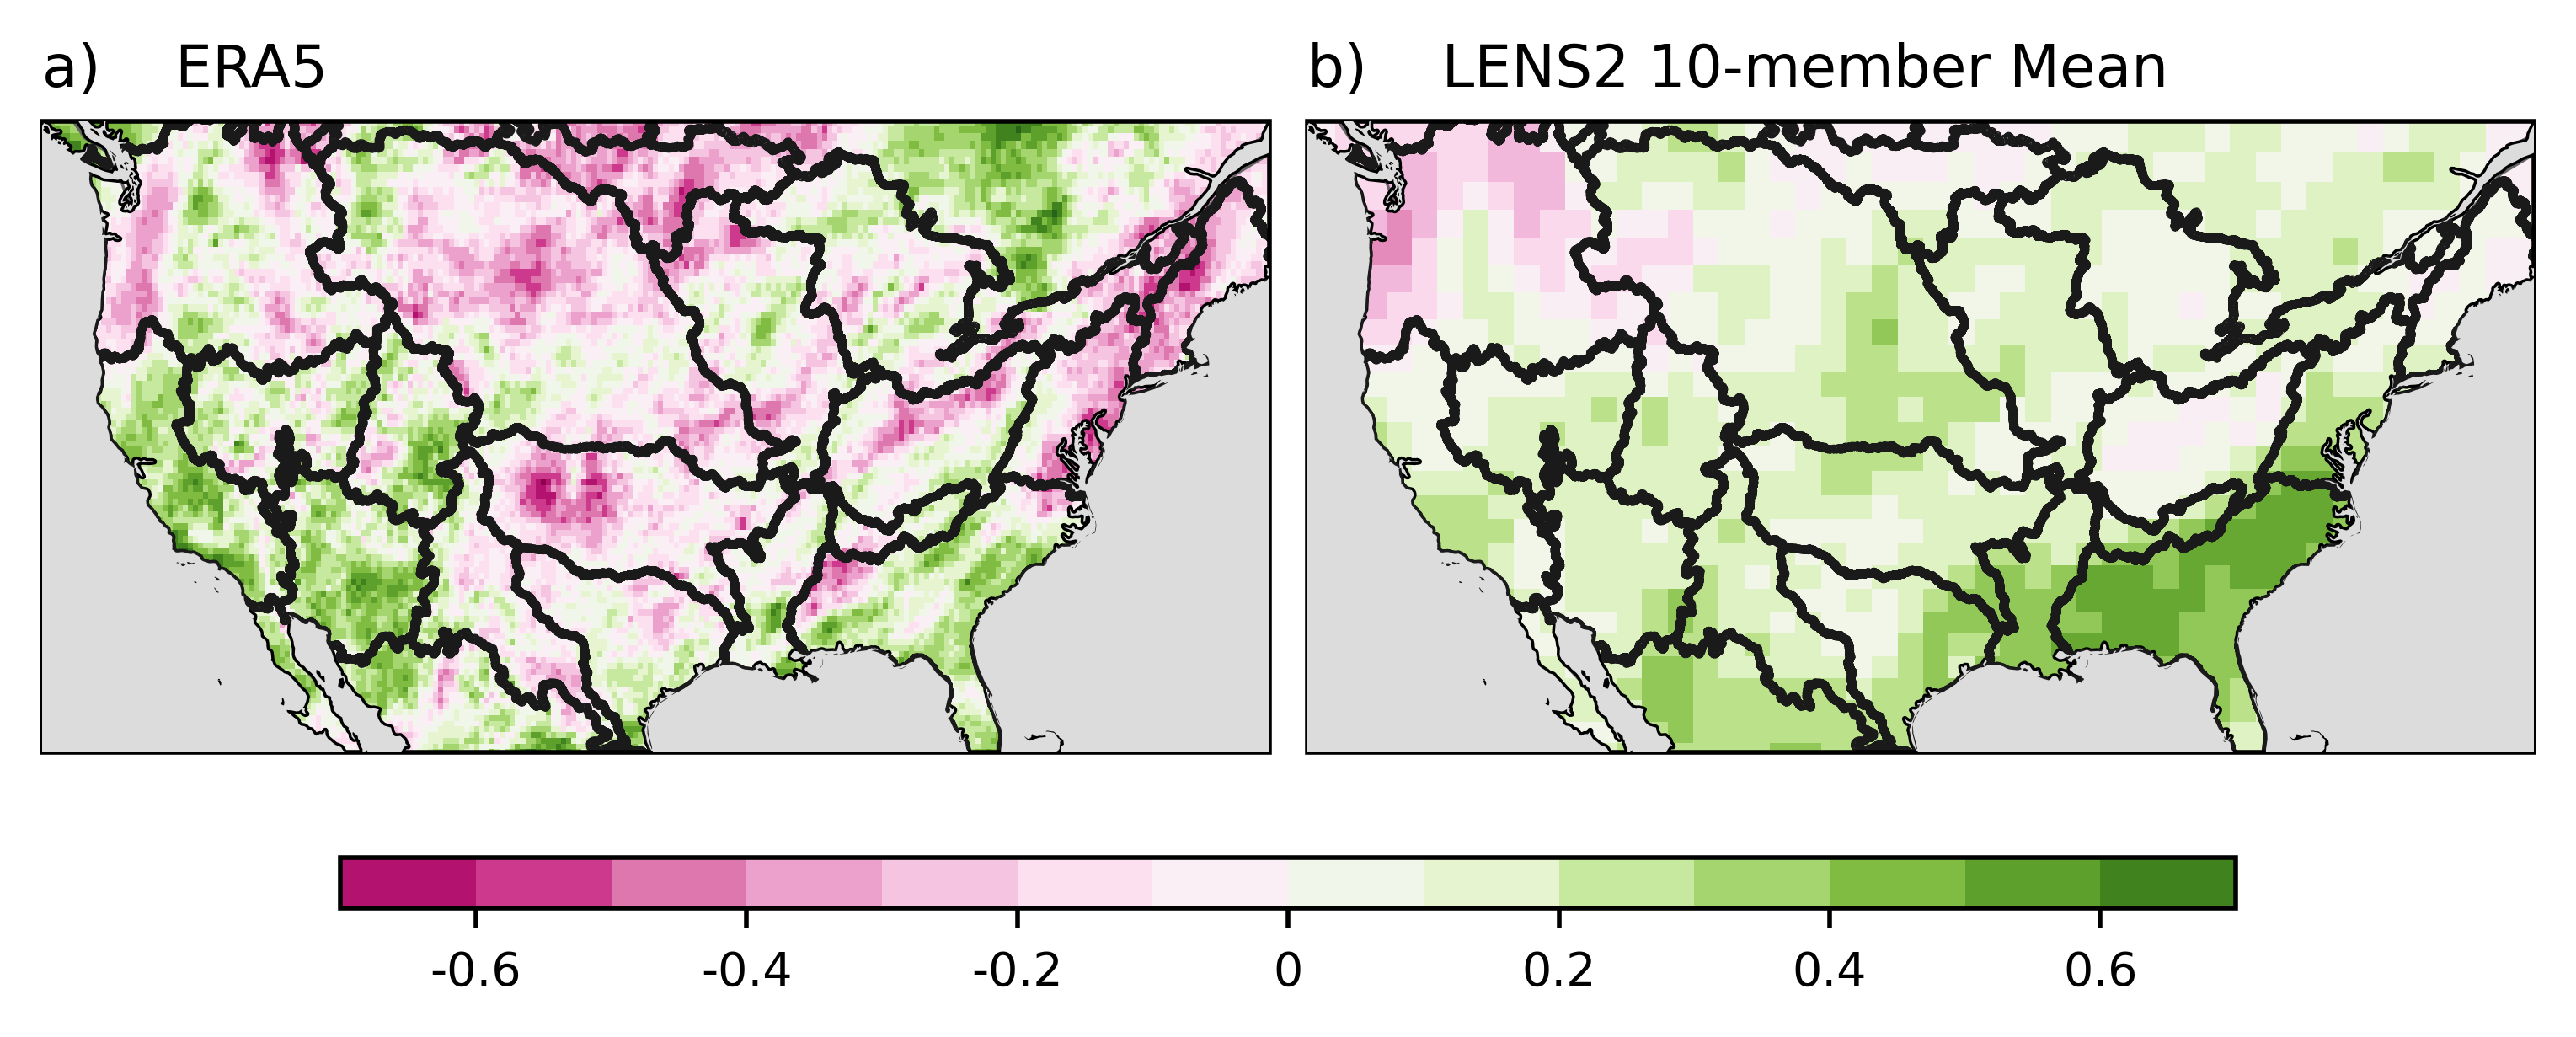

In [75]:
text_kws = dict(
    bbox = dict(color="none"),
    fontsize=8,
    color='none')

fig = plt.figure(figsize=(6, 4), constrained_layout=True, dpi=500)
#spec = gridspec.GridSpec(ncols=2, nrows=1, figure=fig)

# Set spacing between subplots, h/wsapce specified as a fraction of the size of the subplot group
fig.set_constrained_layout_pads(hspace=0.07, wspace=0.03)
vmin  = -0.7
vmax = 0.7
cmap = plt.colormaps.get_cmap('PiYG')
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)


ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.Mercator())
pa = era_r95p_nino34.corr.plot(
      vmin=vmin,vmax=vmax,levels=15,cmap=cmap, norm=norm,
      subplot_kws=dict(projection=ccrs.Robinson(), facecolor="gray"),
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

huc2_regions.plot(ax=ax1, text_kws = text_kws)

ax1.set_title("a)    ERA5", fontsize=10, loc='left')
ax1.coastlines()
ax1.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax1.set_extent([233,293,26,50], crs=ccrs.PlateCarree())


ax2 = fig.add_subplot(1, 2, 2, projection=ccrs.Mercator())
pc = r95p_lens_nino34_10.cor.plot(
      vmin=vmin,vmax=vmax,levels=15,cmap=cmap, norm=norm,
      subplot_kws=dict(projection=ccrs.Robinson(), facecolor="gray"),
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

huc2_regions.plot(ax=ax2, text_kws = text_kws)

ax2.set_title("b)    LENS2 10-member Mean", fontsize=10, loc='left')
ax2.coastlines()
ax2.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax2.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

cax = fig.add_axes([0.125,0.22,0.75,0.03])
cbar_4 = plt.colorbar(pa, cax=cax, orientation='horizontal', extend='neither')
cbar_4.set_ticks(ticks=[-0.6,-0.4,-0.2, 0, 0.2,0.4,0.6], labels=['-0.6','-0.4','-0.2', '0', '0.2','0.4','0.6'])
cbar_4.ax.tick_params(labelsize=8)

plt.savefig(join(plotpath, 'Supp7_NINO34_correlation_comparison.pdf'), dpi=500, bbox_inches='tight')
plt.show()

### Supplemental figure 8 showing all of the CESM correlations

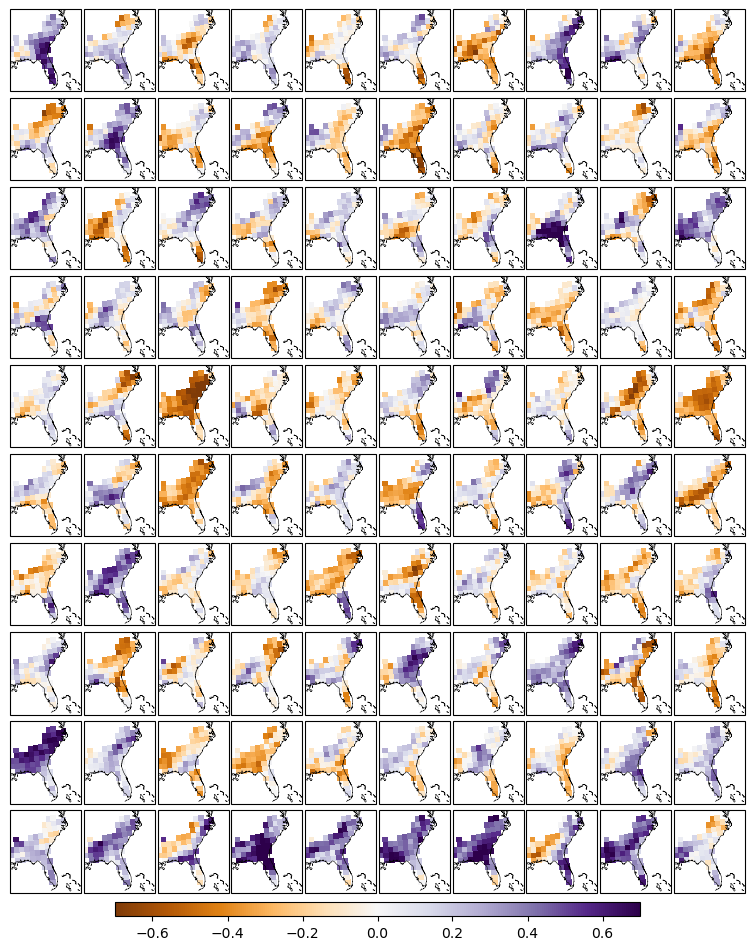

In [86]:
# ── wrangle data ─────────────────────────────────────────────────────────────────
# need to parse out data so that it can be flattened in loop plot.
cor = lens_r95p_ipvh_sahug["cor"]                          # (member, lat, lon)
lats = lens_r95p_ipvh_sahug["lat"].values
lons = lens_r95p_ipvh_sahug["lon"].values
n_members = cor.sizes["member"]

# Convert 0–360 longitudes to −180–180
lons = np.where(lons > 180, lons - 360, lons)

# ── Land mask (True = land) ───────────────────────────────────────────────────
land_shp   = shpreader.natural_earth(resolution="50m", category="physical", name="land")
land_geoms = list(shpreader.Reader(land_shp).geometries())
land_union = unary_union(land_geoms)

LON2D, LAT2D = np.meshgrid(lons, lats)
land_mask = np.array([
    [land_union.contains(Point(LON2D[j, i], LAT2D[j, i]))
     for i in range(LON2D.shape[1])]
    for j in range(LON2D.shape[0])
])

# ── Plot ──────────────────────────────────────────────────────────────────────

PROJ      = ccrs.LambertConformal(central_longitude=-96, central_latitude=37.5)
DATA_PROJ = ccrs.PlateCarree()
EXTENT    = [270, 285, 25, 38]
# this ensures 0 is white
norm      = mcolors.TwoSlopeNorm(vmin=-0.7, vcenter=0, vmax=0.7)

fig, axes = plt.subplots(
    10, 10,
    figsize=(7.5, 9.5),
    subplot_kw={"projection": PROJ},
)

for idx, ax in enumerate(axes.flatten()):
    if idx >= n_members:
        ax.set_visible(False)
        continue

    data = cor.isel(member=idx).values.copy()
    data[~land_mask] = np.nan

    ax.pcolormesh(lons, lats, data, cmap="PuOr", norm=norm,
                  transform=DATA_PROJ, shading="auto")
    ax.set_extent(EXTENT, crs=DATA_PROJ)
    # remove white space reserved for projection curved edges
    ax.set_aspect('auto')
    ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.4, edgecolor="black")
#    ax.add_feature(cfeature.STATES.with_scale("50m"),    linewidth=0.2, edgecolor="0.4")
#    ax.add_feature(cfeature.BORDERS.with_scale("50m"),   linewidth=0.4, edgecolor="black")
    #ax.set_title(f"Member {idx + 1}", fontsize=3.5, pad=1)

# Colorbar
cbar_ax = fig.add_axes([0.15, 0.03, 0.70, 0.015])
sm = plt.cm.ScalarMappable(cmap="PuOr", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", extend="neither")
#cbar.set_label("Correlation", fontsize=8)
cbar.ax.tick_params(labelsize=10)

#fig.suptitle("CESM2 Large Ensemble — Correlations (CONUS)",
#             fontsize=10, y=0.995, fontweight="bold")
plt.subplots_adjust(left=0.01, right=0.99, top=0.985, bottom=0.055,
                    wspace=0.04, hspace=0.08)

fig.savefig(join(plotpath, 'Supp8_cesm2_correlations_huc2sag.pdf'), dpi=500, bbox_inches="tight")
plt.show()

### Supplemental Figure 9 Time series of ERA5 and LENS2 IPV vs R95p

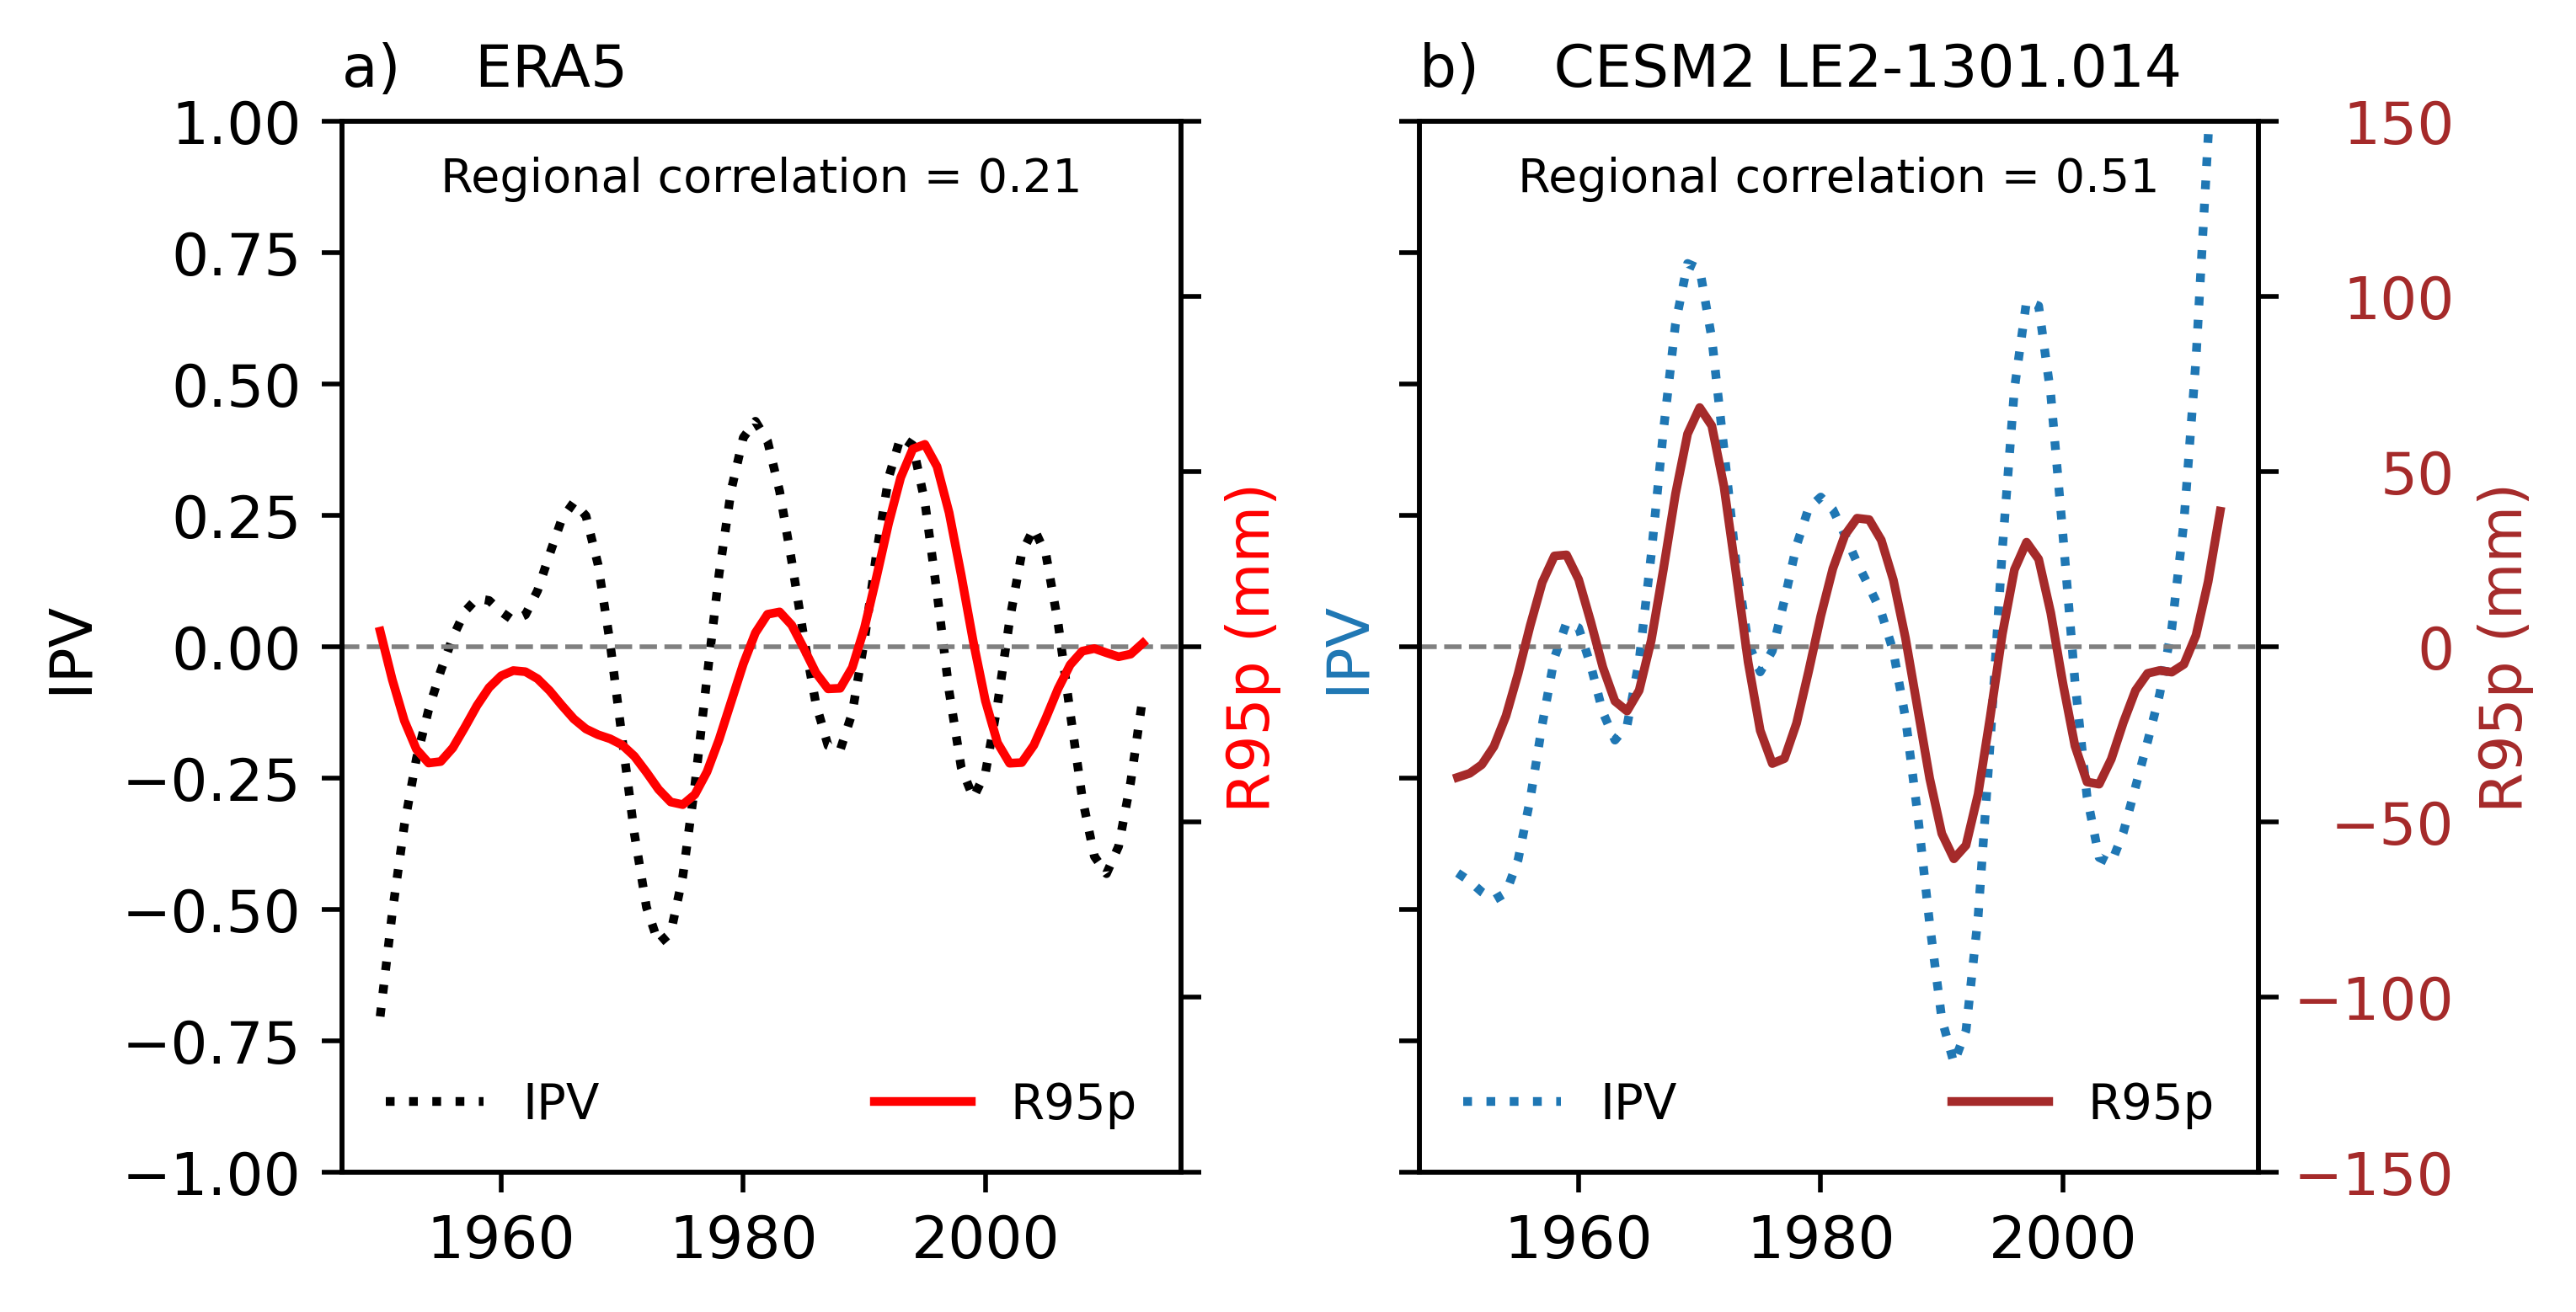

In [61]:
fig = plt.figure(constrained_layout=True, dpi=500, figsize=(6, 3)) 
spec = gridspec.GridSpec(ncols=2, nrows=1, figure=fig)

# Set spacing between subplots, h/wsapce specified as a fraction of the size of the subplot group
fig.set_constrained_layout_pads(hspace=0.07, wspace=0.03)
ax1 = fig.add_subplot(spec[0, 0])
plt.plot(era_ipvh.year, era_ipvh.ipvh, label = "IPV", color='black', linestyle=':')
ax1.axhline(y=0, color="grey", linestyle="--", linewidth=.8)
ax1.set_ylim(-1,1)
plt.legend(loc='lower left', frameon=False, fontsize='small')
ax1.set_title("a)    ERA5", fontsize=10, loc='left')
ax1.set_ylabel('IPV')

ax2 = ax1.twinx()
plt.plot(r95p_sag_era.year, r95p_sag_era.R95p,label = 'R95p', color='red')
ax2.set_ylim(-150,150)
ax2.tick_params(labelright=False)
ax2.yaxis.set_tick_params(which='major', labelcolor='red')
ax2.text(1955, 130,
        f'Regional correlation = {weighted_cors.ERA5_cor.values.round(decimals=2)}',
        fontsize=8)
ax2.set_ylabel('R95p (mm)', color='red')

plt.legend(loc='lower right', frameon=False, fontsize='small')

ax3 = fig.add_subplot(spec[0, 1])
plt.plot(lens_ipvh.year, lens_ipvh.IPVH.isel(member=93), linestyle=':', label='IPV')
ax3.axhline(y=0, color="grey", linestyle="--", linewidth=.8)
ax3.set_ylim(-1,1)
ax3.set_ylabel('IPV',color='tab:blue')
ax3.tick_params(labelleft=False)
ax3.legend(loc='lower left', frameon=False, fontsize='small')
ax3.set_title("b)    CESM2 LE2-1301.014", fontsize=10, loc='left')

ax4 = ax3.twinx()
plt.plot(lens_huc2_r95p.year, lens_huc2_r95p.R95p.sel(member=members_10[0]), color='brown', label='R95p')
ax4.set_ylim(-150,150)
# right-align all ticklabels
for ticklabel in ax4.get_yticklabels():
    ticklabel.set_horizontalalignment("right")
# increase padding
ax4.tick_params("y", pad=30)
ax4.yaxis.set_tick_params(which='major', labelcolor='brown')
ax4.set_ylabel('R95p (mm)', color='brown')
ax4.legend(loc='lower right', frameon=False, fontsize='small')
ax4.text(1955, 130,
        f'Regional correlation = {weighted_cors.LENS2_cor.sel(member=94).values.round(decimals=2)}',
        fontsize=8)

fig.savefig(join(plotpath, 'SuppFigure9_SAG_timeseries_IPV_R95p.pdf'), dpi=300, bbox_inches="tight")
plt.show()

##### Supplemental Figure 10

Comparison of E3SM to obs

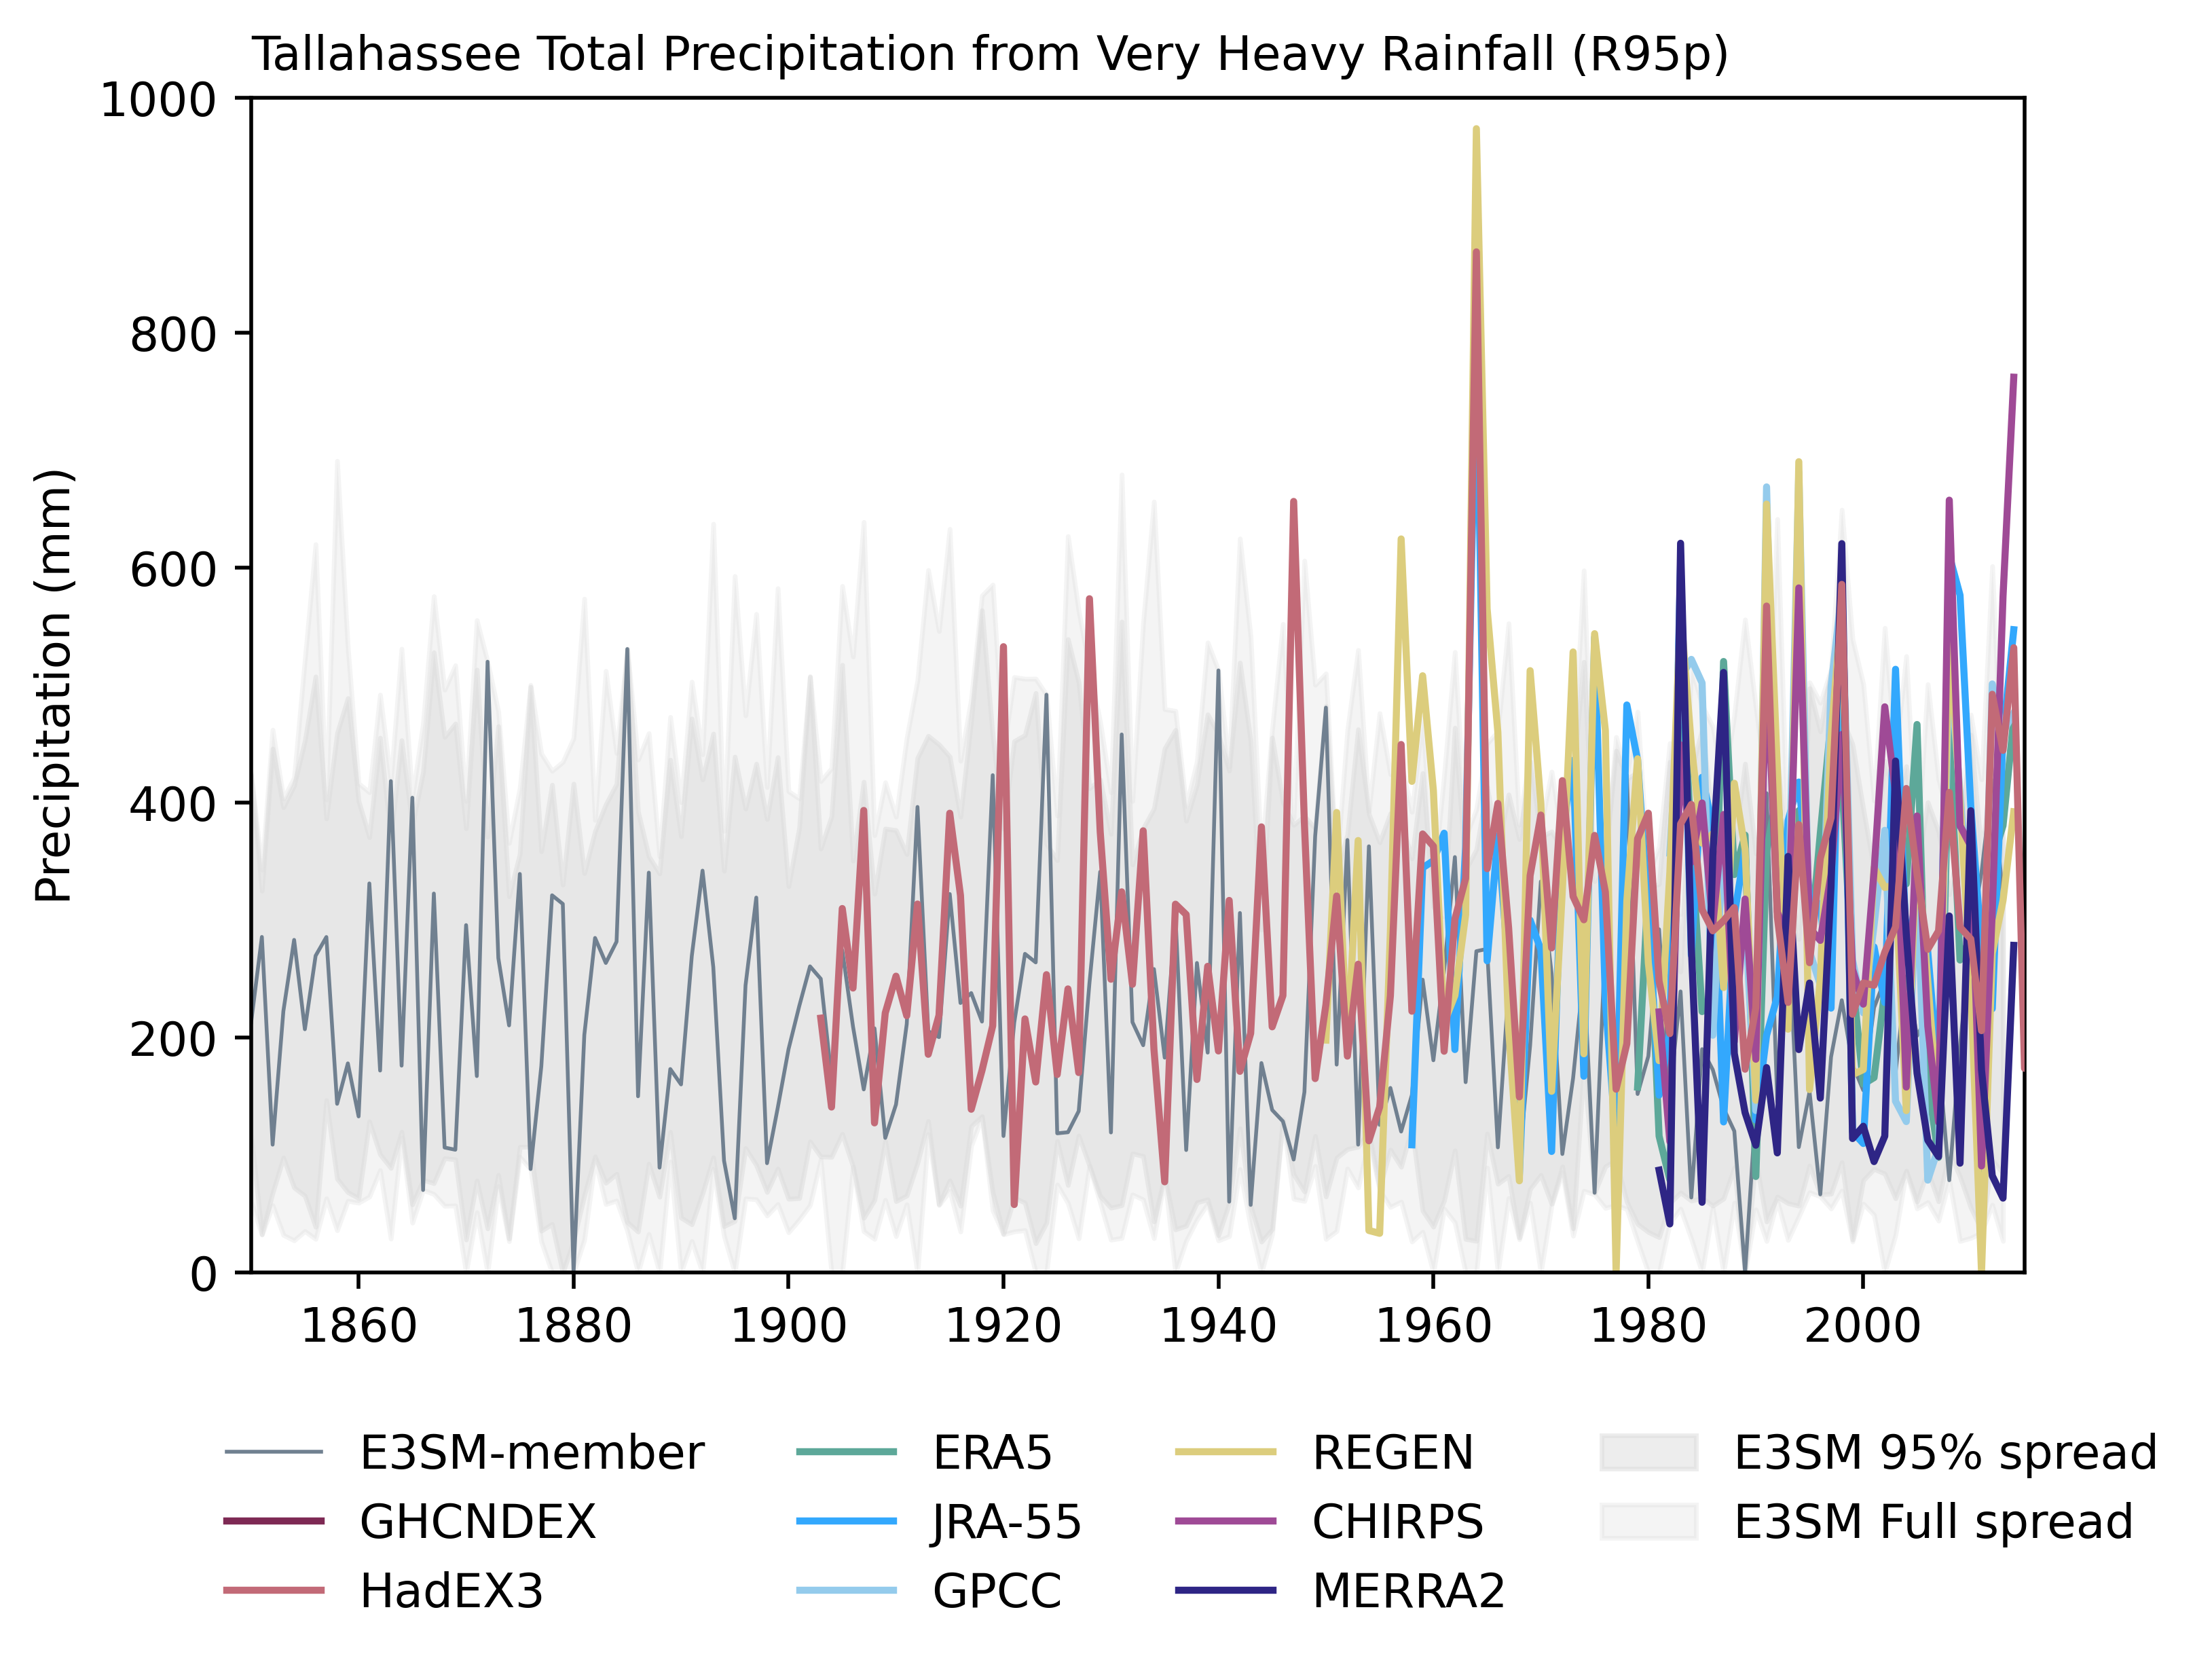

In [33]:
# Comparison of R95p to ERA5
fig = plt.figure(constrained_layout=True, dpi=500) 

ax5 = fig.add_subplot(1,1,1)
ax5.plot(r95p_e3sm_tal.year, r95p_e3sm_tal.R95p_ind, label='E3SM-member', color='slategrey', linewidth=0.8)
ax5.plot(ghx_t.time.dt.year, ghx_t.R95p, label='GHCNDEX', color=(126/255, 41/255, 84/255), zorder=10)
ax5.plot(had_t.time.dt.year, had_t.R95p, label='HadEX3', color=(194/255,106/255,119/255), zorder=10)
ax5.plot(era_t.year, era_t.R95p, label='ERA5', color=(93/255,168/255,153/255))
ax5.plot(jra_t.year, jra_t.R95p, label='JRA-55', color=(51/255,168/255,253/255))
ax5.plot(gpc_t.year, gpc_t.R95p, label='GPCC', color=(148/255,203/255,236/255))
ax5.plot(reg_t.year, reg_t.R95p, label='REGEN', color=(220/255,205/255,125/255))
ax5.plot(chp_t.year, chp_t.R95p, label='CHIRPS', color= (159/255,74/255,150/255) )
ax5.plot((mer_t.year), mer_t.rain, label='MERRA2', color=(46/255,37/255,133/255))
ax5.fill_between(r95p_e3sm_tal.year, r95p_e3sm_tal.R95p_5per, r95p_e3sm_tal.R95p_95per, alpha=0.5, color= 'gainsboro' , label='E3SM 95% spread')
ax5.fill_between(r95p_e3sm_tal.year, r95p_e3sm_tal.R95p_min, r95p_e3sm_tal.R95p_max, alpha=0.3, color='gainsboro', label='E3SM Full spread')

ax5.set_xlim(1850,2015)
ax5.set_ylim(0,1000)
ax5.set_ylabel('Precipitation (mm)')
ax5.set_title('Tallahassee Total Precipitation from Very Heavy Rainfall (R95p)', loc='left',fontsize=10)
ax5.legend(bbox_to_anchor=(1.1, -0.1), shadow=False, ncols = 4, frameon=False)

plt.savefig(join(plotpath,'Supp10_R95p_ONDJFM_ERA5_E3SM_FLts.pdf'),bbox_inches='tight', dpi=500)
plt.show()

##### Supplemental Figure 11

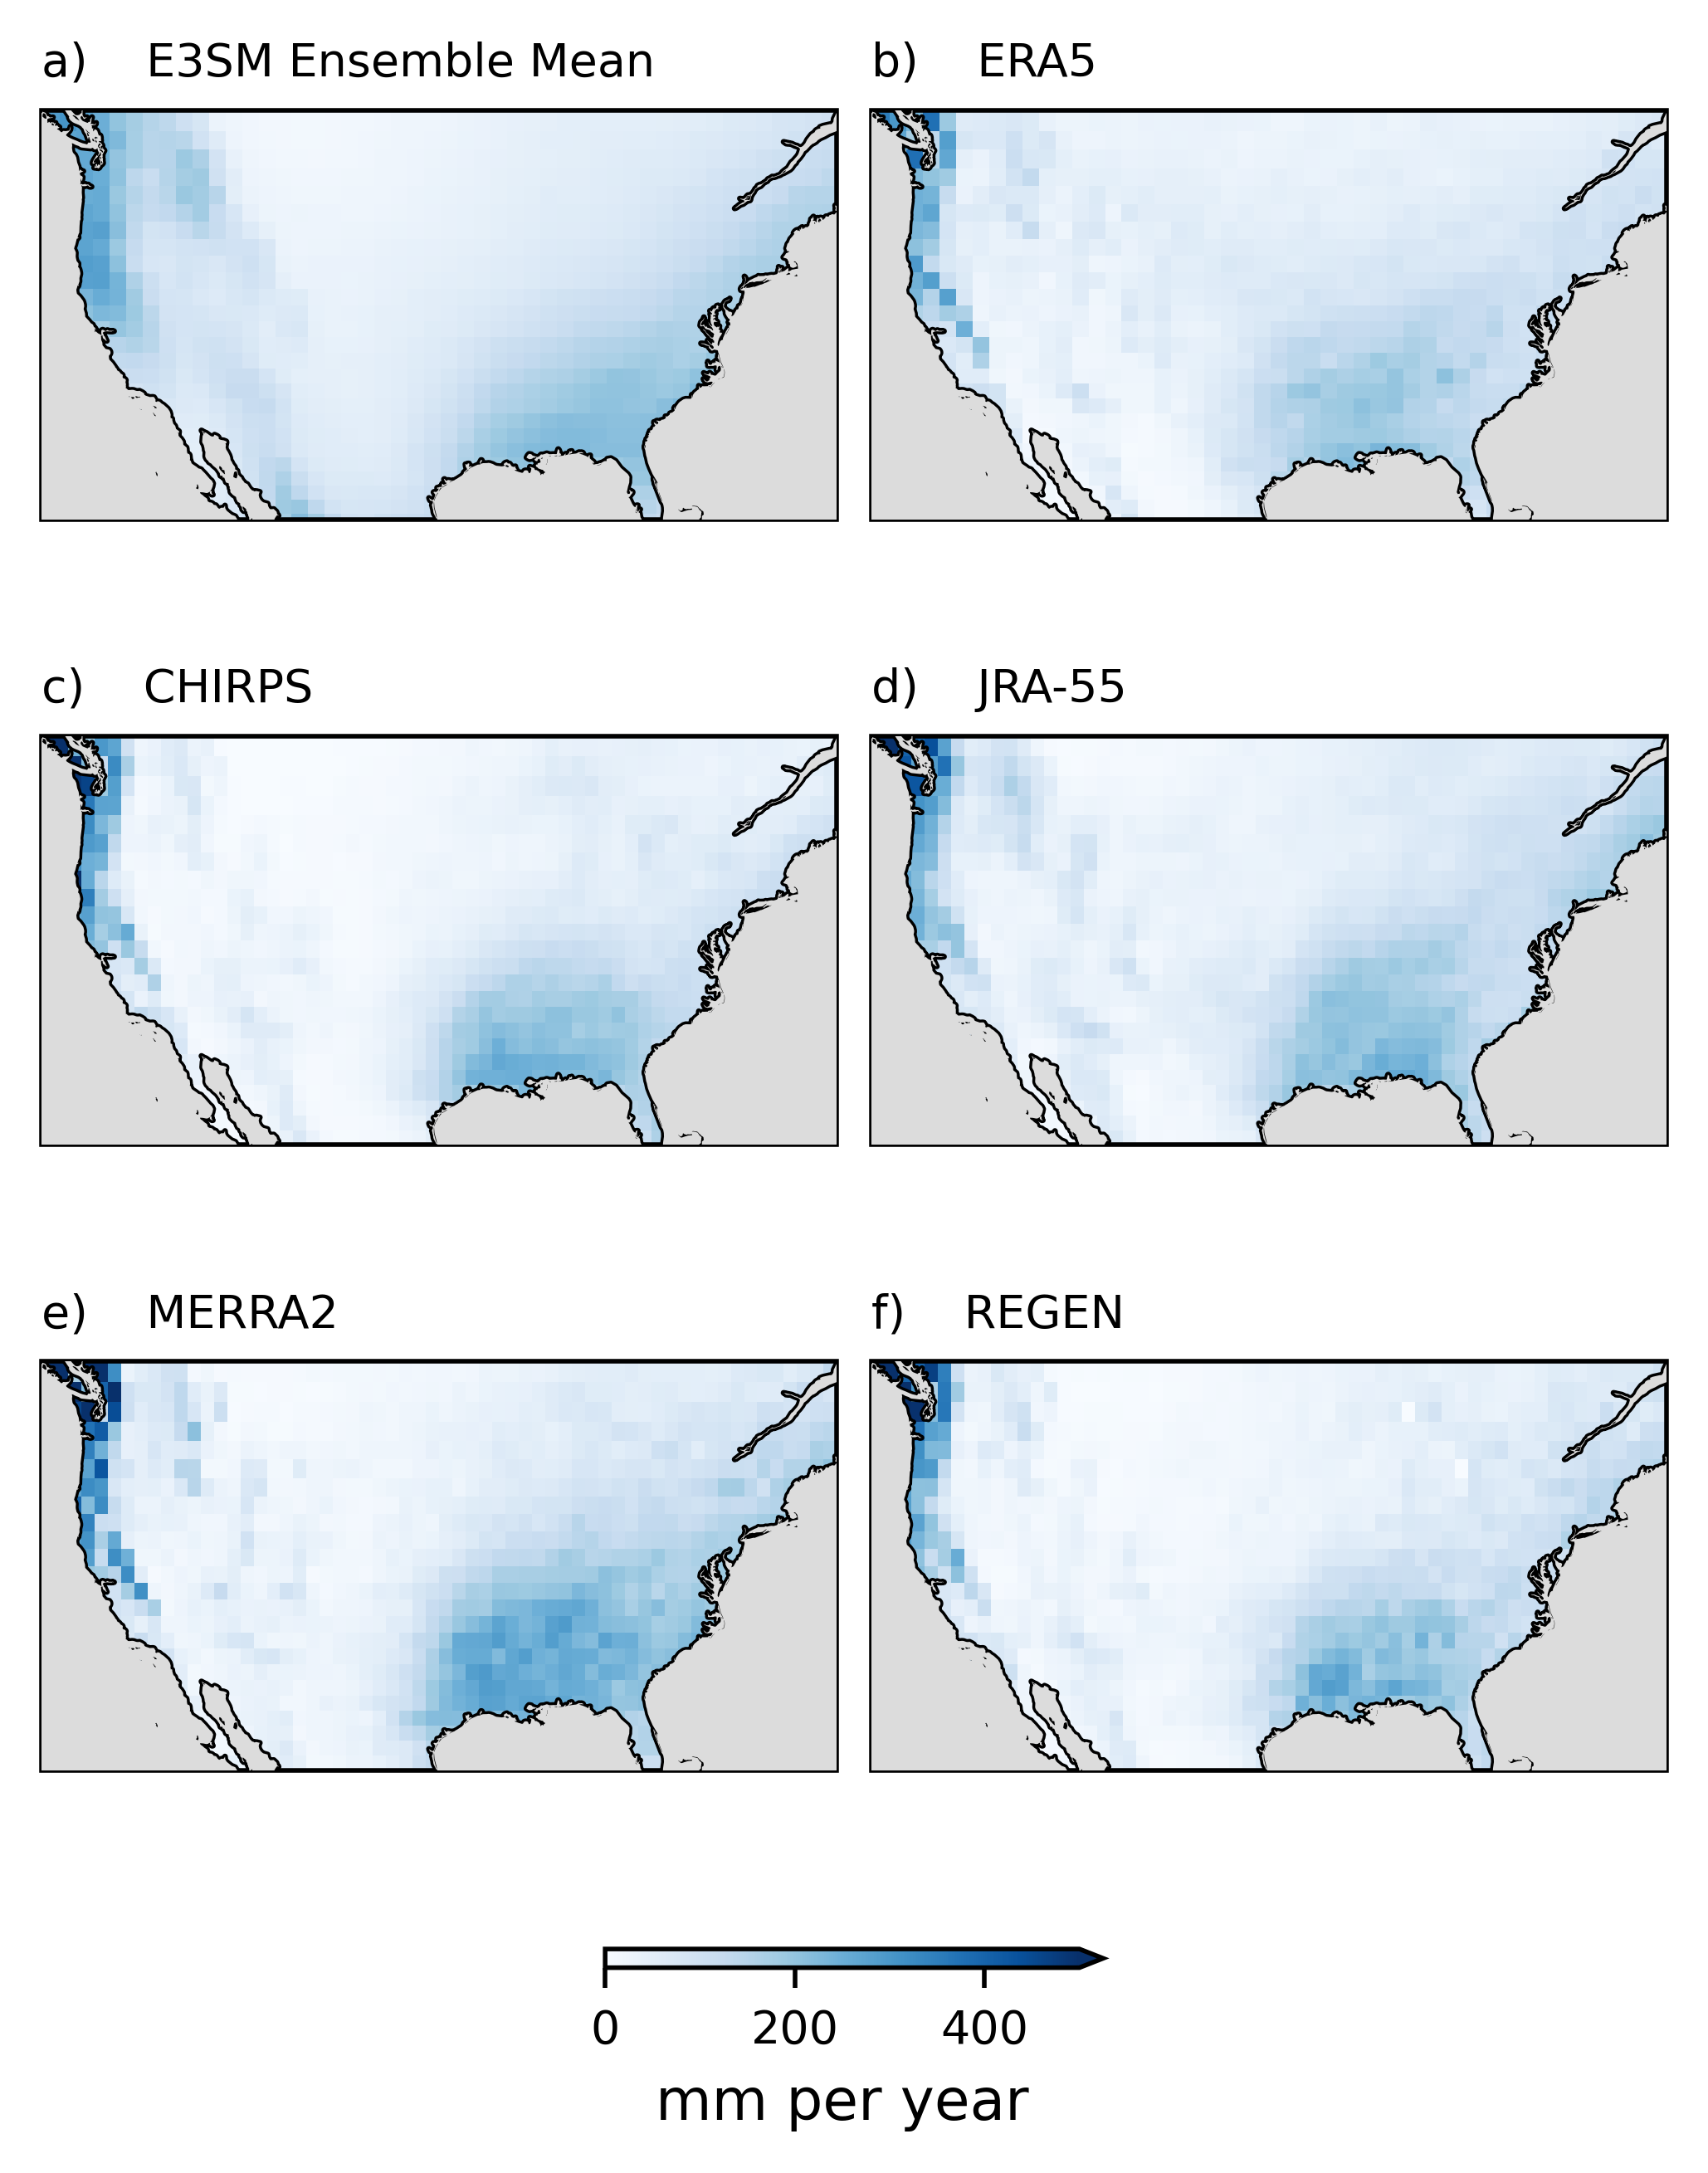

In [34]:
# R95p comparison of LENS and observations
fig = plt.figure(figsize=(4, 4.5), constrained_layout=True, dpi=500)

# Set spacing between subplots, h/wsapce specified as a fraction of the size of the subplot group
fig.set_constrained_layout_pads(hspace=0.07, wspace=0.03)
vmin  = 0
vmax = 500

ax1 = fig.add_subplot(3, 2, 1, projection=ccrs.Mercator())
pa = r95p_e3sm_8110.R95p.plot(
      cmap='Blues',
      vmax = vmax, vmin=vmin,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)
ax1.set_title("a)    E3SM Ensemble Mean", fontsize=8, loc='left')
ax1.coastlines()
ax1.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax1.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

ax2 = fig.add_subplot(3, 2, 2, projection=ccrs.Mercator())
pb = r95p_ellin_8110.R95p.plot(
      cmap='Blues',
      vmax = vmax, vmin=vmin,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

ax2.set_title("b)    ERA5", fontsize=8, loc='left')
ax2.coastlines()
ax2.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax2.set_extent([233,293,26,50], crs=ccrs.PlateCarree())


ax3 = fig.add_subplot(3, 2, 3, projection=ccrs.Mercator())
pc = r95p_c_8110.rain.plot(
      cmap='Blues',
      vmax = vmax, vmin=vmin,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)
ax3.set_title("c)    CHIRPS", fontsize=8, loc='left')
ax3.coastlines()
ax3.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax3.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

ax4 = fig.add_subplot(3, 2, 4, projection=ccrs.Mercator())
pd = r95p_j_8110.rain.plot(
      cmap='Blues',
      vmax = vmax, vmin=vmin,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

ax4.set_title("d)    JRA-55", fontsize=8, loc='left')
ax4.coastlines()
ax4.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax4.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

ax5 = fig.add_subplot(3, 2, 5, projection=ccrs.Mercator())
pd = r95p_m_8110.rain.plot(
      cmap='Blues',
      vmax = vmax, vmin=vmin,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

ax5.set_title("e)    MERRA2", fontsize=8, loc='left')
ax5.coastlines()
ax5.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax5.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

ax6 = fig.add_subplot(3, 2, 6, projection=ccrs.Mercator())
pd = r95p_r_8110.rain.plot(
      cmap='Blues',
      vmax = vmax, vmin=vmin,
      transform=ccrs.PlateCarree(),
      add_colorbar=False)

ax6.set_title("f)    REGEN", fontsize=8, loc='left')
ax6.coastlines()
ax6.add_feature(cartopy.feature.OCEAN, zorder=10, facecolor='gainsboro', edgecolor='none')
ax6.set_extent([233,293,26,50], crs=ccrs.PlateCarree())

cax = fig.add_axes([0.35,-0.05,0.3,0.01])
cbar_3 = plt.colorbar(pc, cax=cax, orientation='horizontal', extend='max')
cbar_3.set_label(label = 'mm per year', size=10)
cbar_3.ax.tick_params(labelsize=8)


#plt.suptitle('ONDJFM Total Precipitation >95% 1981-2010')
plt.savefig(join(plotpath,'Supp11_R95p_ONDJFM_OBS_E3SM_1981-2010.pdf'),bbox_inches='tight')
plt.show()